Student Names

- Julie DORNAT
- Sukhjot KAUR
- Oloruntobi Paul OLUTOLA


# End-To-End Memory Networks (MemN2N)

**Paper:** Sukhbaatar et al., "End-To-End Memory Networks", NeurIPS 2015 — [arXiv:1503.08895](https://arxiv.org/abs/1503.08895)

---

Most neural networks process a fixed-size input and produce an output in a single forward pass.  The problem with question answering is that the context (a story, a document, a set of facts) is variable-length, sometimes very long, and only a few sentences in it are actually relevant to any given question.  A standard RNN would have to compress everything into a single hidden state; a transformer would attend over everything indiscriminately.

MemN2N takes a different approach: it keeps the context as an explicit **external memory** — a list of sentence vectors — and learns to **query that memory multiple times** ("hops") before outputting an answer.  Each hop refines the model's understanding of which memory slots matter.  The entire system, including the memory read and write operations, is differentiable and trained end-to-end with standard backpropagation.

The key difference from the original Memory Networks (Weston et al. 2015) is that MemN2N requires **no intermediate supervision** — you only need (story, question, answer) triples, not labels telling the model which sentences are the supporting facts.

---

### What this notebook covers

1. **bAbI dataset** — 20 synthetic reasoning tasks with known difficulty profiles  
2. **Preprocessing** — how text becomes padded integer tensors  
3. **Baseline: LSTM** — a strong sequential model that does not use explicit memory  
4. **MemN2N implementation** — according to the paper 
5. **Training** — includes the Linear Start trick that the paper uses to avoid local minima  
6. **Comparison** — our results vs. LSTM vs those of the paper 
7. **Attention visualisation** — hop-by-hop heatmaps showing how the model reasons


## 1. Setup and Dependencies

In [1]:
import os
import math
import urllib
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from tqdm.auto import tqdm
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

import tarfile

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

def _get_device():
    if not torch.cuda.is_available():
        return torch.device('cpu')
    try:
        torch.zeros(1).cuda()
        return torch.device('cuda')
    except Exception:
        return torch.device('cpu')

DEVICE = _get_device()
PIN_MEMORY  = DEVICE.type == 'cuda'
NUM_WORKERS = 2 if DEVICE.type == 'cuda' else 0

print(f'Using device: {DEVICE}  |  pin_memory={PIN_MEMORY}  |  num_workers={NUM_WORKERS}')

os.makedirs("/kaggle/working/images", exist_ok=True)

Using device: cuda  |  pin_memory=True  |  num_workers=2


---
## Data Loading bAbI

The bAbI dataset consists of 20 synthetic QA tasks, each designed to test a specific type of reasoning (e.g., path finding, coreference, counting). Each sample is a list of sentences (the story), a question, and a single-word answer.

In [2]:
# Download bAbI dataset if not already present
BABI_URL = 'https://s3.amazonaws.com/text-datasets/babi_tasks_1-20_v1-2.tar.gz'
BASE_DIR = '/kaggle/working' if os.path.exists('/kaggle/working') else '../'
BABI_DIR = os.path.join(BASE_DIR, 'babi_data')


is_data_downloaded = os.path.exists(os.path.join(BABI_DIR, 'tasks_1-20_v1-2', 'en-10k'))
if not is_data_downloaded:
    print('Downloading bAbI dataset...')
    os.makedirs(BABI_DIR, exist_ok=True)
    tar_path = os.path.join(BASE_DIR, 'babi.tar.gz')
    urllib.request.urlretrieve(BABI_URL, tar_path)
    with tarfile.open(tar_path) as f:
        f.extractall(BABI_DIR)
    os.remove(tar_path)
    print('Done.')
else:
    print('bAbI data already downloaded.')

bAbI data already downloaded.


---
## 2. Dataset Analysis

Before building anything, it's worth spending a few minutes actually looking at the data. The bAbI dataset has 20 tasks — each one tests a different kind of reasoning. Here we'll get a feel for the scale, structure, and what the model is actually being asked to do.

In [8]:
data_dir = os.path.join(BABI_DIR, 'tasks_1-20_v1-2', 'en-10k')

TASK_NAMES = {
    1: 'single-supporting-fact', 2: 'two-supporting-facts',
    3: 'three-supporting-facts', 4: 'two-arg-relations',
    5: 'three-arg-relations',    6: 'yes-no-questions',
    7: 'counting',               8: 'lists-sets',
    9: 'simple-negation',        10: 'indefinite-knowledge',
    11: 'basic-coreference',     12: 'conjunction',
    13: 'compound-coreference',  14: 'time-reasoning',
    15: 'basic-deduction',       16: 'basic-induction',
    17: 'positional-reasoning',  18: 'size-reasoning',
    19: 'path-finding',          20: 'agents-motivations'
}

def parse_task(path):
    stories, story_lens, answers = 0, [], []
    cur_len = 0
    with open(path) as f:
        for line in f:
            idx = int(line.strip().split(' ', 1)[0])
            if idx == 1 and cur_len > 0:
                story_lens.append(cur_len); cur_len = 0; stories += 1
            cur_len += 1
            if '\t' in line:
                answers.append(line.strip().split('\t')[1].strip().lower())
    if cur_len: story_lens.append(cur_len); stories += 1
    return stories, story_lens, answers

stats = {}
for tid in range(1, 21):
    tr = [f for f in os.listdir(data_dir) if f.startswith('qa%d_' % tid) and 'train' in f][0]
    te = [f for f in os.listdir(data_dir) if f.startswith('qa%d_' % tid) and 'test'  in f][0]
    tr_s, tr_lens, tr_ans = parse_task(os.path.join(data_dir, tr))
    te_s, te_lens, te_ans = parse_task(os.path.join(data_dir, te))
    stats[tid] = dict(
        name=TASK_NAMES[tid], tr_stories=tr_s, te_stories=te_s,
        tr_qa=len(tr_ans), avg_story_len=round(sum(tr_lens)/len(tr_lens), 1),
        unique_ans=len(set(tr_ans + te_ans)), answers=tr_ans + te_ans
    )

total_train_qa = sum(s['tr_qa'] for s in stats.values())
total_words = sum(
    len(line.split()) for fname in os.listdir(data_dir)
    if fname.endswith('.txt')
    for line in open(os.path.join(data_dir, fname))
)

print("=== bAbI Dataset — Quick Overview ===\n")
print(f"20 tasks, each testing a different reasoning skill")
print(f"{total_train_qa:,} training QA pairs in total (10k per task)")
print(f"~{total_words:,} total word tokens across all files")
print(f"Vocabulary: only ~145 unique words — intentionally tiny")
print()

# Hardest tasks by average story length
sorted_by_len = sorted(stats.items(), key=lambda x: x[1]['avg_story_len'], reverse=True)
print("Tasks with the longest stories (most context to remember):")
for tid, s in sorted_by_len[:5]:
    print(f"Task {tid:>2} ({s['name']:<20}) avg {s['avg_story_len']:>5} lines/story")

print()
print("Tasks with the smallest answer space (almost binary):")
for tid, s in stats.items():
    if s['unique_ans'] <= 2:
        print(f"Task {tid:>2} ({s['name']:<20}) only {s['unique_ans']} possible answers")


=== bAbI Dataset — Quick Overview ===

20 tasks, each testing a different reasoning skill
200,000 training QA pairs in total (10k per task)
~6,658,468 total word tokens across all files
Vocabulary: only ~145 unique words — intentionally tiny

Tasks with the longest stories (most context to remember):
Task  3 (three-supporting-facts) avg  79.4 lines/story
Task  5 (three-arg-relations ) avg  32.3 lines/story
Task  2 (two-supporting-facts) avg  27.0 lines/story
Task 20 (agents-motivations  ) avg  21.4 lines/story
Task  8 (lists-sets          ) avg  18.3 lines/story

Tasks with the smallest answer space (almost binary):
Task  6 (yes-no-questions    ) only 2 possible answers
Task  9 (simple-negation     ) only 2 possible answers
Task 17 (positional-reasoning) only 2 possible answers
Task 18 (size-reasoning      ) only 2 possible answers


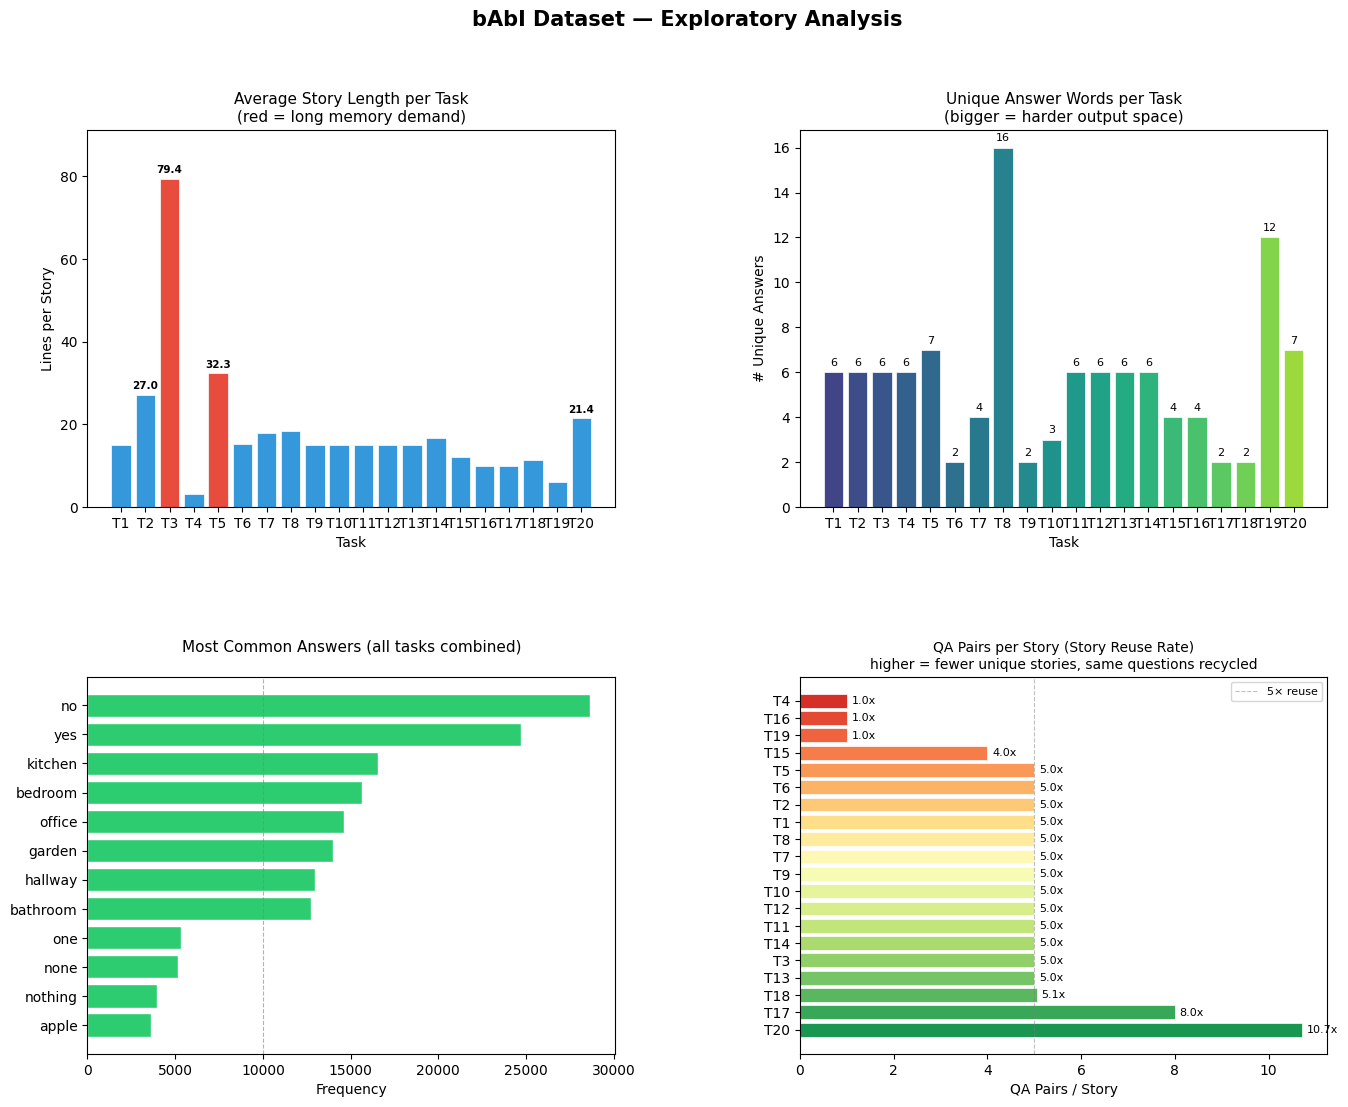

Figure saved to babi_analysis.png


In [9]:
fig = plt.figure(figsize=(16, 12))
fig.suptitle('bAbI Dataset — Exploratory Analysis', fontsize=15, fontweight='bold', y=0.98)
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

task_ids    = list(range(1, 21))
task_labels = ['T%d' % i for i in task_ids]
avg_lens    = [stats[i]['avg_story_len'] for i in task_ids]
unique_ans  = [stats[i]['unique_ans']    for i in task_ids]

# 1. Average story length per task
ax1 = fig.add_subplot(gs[0, 0])
colors = ['#e74c3c' if l > 30 else '#3498db' for l in avg_lens]
bars = ax1.bar(task_labels, avg_lens, color=colors, edgecolor='white', linewidth=0.5)
ax1.set_title('Average Story Length per Task\n(red = long memory demand)', fontsize=11)
ax1.set_xlabel('Task'); ax1.set_ylabel('Lines per Story')
ax1.set_ylim(0, max(avg_lens) * 1.15)
for bar, v in zip(bars, avg_lens):
    if v > 20:
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 str(v), ha='center', va='bottom', fontsize=7.5, fontweight='bold')

# 2. Answer vocabulary size per task
ax2 = fig.add_subplot(gs[0, 1])
palette = plt.cm.viridis(np.linspace(0.2, 0.85, len(task_ids)))
ax2.bar(task_labels, unique_ans, color=palette, edgecolor='white', linewidth=0.5)
ax2.set_title('Unique Answer Words per Task\n(bigger = harder output space)', fontsize=11)
ax2.set_xlabel('Task'); ax2.set_ylabel('# Unique Answers')
for i, v in enumerate(unique_ans):
    ax2.text(i, v + 0.2, str(v), ha='center', va='bottom', fontsize=8)

# 3. Global answer frequency (top 12)
ax3 = fig.add_subplot(gs[1, 0])
all_answers = [a for s in stats.values() for a in s['answers']]
top_ans = Counter(all_answers).most_common(12)
words, cnts = zip(*top_ans)
ax3.barh(list(reversed(words)), list(reversed(cnts)), color='#2ecc71', edgecolor='white')
ax3.set_title('Most Common Answers (all tasks combined)\n', fontsize=11)
ax3.set_xlabel('Frequency')
ax3.axvline(x=10000, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)

# 4. QA pairs per story (story reuse rate)
ax4 = fig.add_subplot(gs[1, 1])
tr_stories = [stats[i]['tr_stories'] for i in task_ids]
tr_qa      = [stats[i]['tr_qa']      for i in task_ids]
qa_per_story = [q / s for q, s in zip(tr_qa, tr_stories)]

cmap_vals = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(task_ids)))
sorted_idx = np.argsort(qa_per_story)[::-1]
sorted_labels = [task_labels[i] for i in sorted_idx]
sorted_vals   = [qa_per_story[i] for i in sorted_idx]
sorted_colors = [cmap_vals[rank] for rank, _ in enumerate(sorted_idx)]

h_bars = ax4.barh(sorted_labels, sorted_vals, color=sorted_colors, edgecolor='white', linewidth=0.5)
ax4.set_title('QA Pairs per Story (Story Reuse Rate)\nhigher = fewer unique stories, same questions recycled', fontsize=10)
ax4.set_xlabel('QA Pairs / Story')
ax4.axvline(x=5, color='gray', linestyle='--', linewidth=0.8, alpha=0.5, label='5× reuse')
ax4.legend(fontsize=8)
for bar, v in zip(h_bars, sorted_vals):
    ax4.text(v + 0.1, bar.get_y() + bar.get_height()/2,
             '%.1fx' % v, va='center', fontsize=8)

plt.savefig('../images/babi_analysis.png', dpi=130, bbox_inches='tight')
plt.show()
print("Figure saved to babi_analysis.png")


### What the data is telling us

First thing that jumps out the vocabulary is only ~145 words. That's not a typo. This dataset was never meant to test whether a model understands language; it's testing whether it can reason over it. The words are simple. The logic isn't.

Story length is probably the most honest measure of difficulty here. Most tasks sit around 15 lines, which is manageable. Task 3 though? Average of 79 lines per story. The model has to read through all of that, figure out which three sentences actually matter, and ignore the rest. That's where a lot of memory architectures quietly fall apart.

Something that's easy to miss: every task has exactly 10k QA pairs, but the number of actual stories behind them is all over the place. Task 20 only has 933 unique stories so those same stories are being asked about roughly 10 different times each. A model that just memorizes the templates will look fine on paper but hasn't really learned anything.

On the answer side, tasks 6, 9, 17, and 18 only have two possible answers. Yes/no, left/right. Random guessing already gets you 50% there, so high accuracy on those doesn't say much. Task 8 is the opposite, it has 16 unique answers and that's where you'd actually expect a weaker model to struggle.

The location words (kitchen, bedroom, office, garden) absolutely dominate the answer distribution across all tasks combined. Makes sense given how many tasks are about tracking where people go, but it's worth knowing in case you're looking at aggregate stats and wondering why the model seems biased toward place names.

---
## 3. Preprocessing

- Parse stories: returns story, query and answer
- Build vocab: retrieve the vocabulary V
- Vectorize with Bag of Words: create a vector giving the position of each word of the sentence in the vocabulary. Instead of generate one hot vector of size |V| for each word of the sentence, we directly retrieve the position of the word in the vocabulary.

In [10]:
def parse_stories(path):
    data, story = [], []
    with open(path) as f:
        for line in f:
            line = line.strip().lower()
            idx, line = line.split(' ', 1)
            idx = int(idx)
            if idx == 1:
                story = []
            if '\t' in line:
                q, a, _ = line.split('\t')
                data.append((list(story), q, a))
            else:
                story.append(line.rstrip('.'))
    return data


def build_vocab(datasets):
    vocab = set()
    for data in datasets:
        for story, q, a in data:
            for sent in story:
                vocab.update(sent.split())
            vocab.update(q.split())
            vocab.add(a)
    word2idx = {w: i+1 for i, w in enumerate(sorted(vocab))}
    word2idx['<pad>'] = 0
    return word2idx


def vectorize(data, word2idx, memory_size=50, sentence_size=11):
    stories, queries, answers = [], [], []

    for story, q, a in data:
        def encode_sent(sent):
            words = sent.split()[:sentence_size]
            indices = [word2idx.get(w, 0) for w in words]
            indices += [0] * (sentence_size - len(indices))
            return indices

        encoded_story = [encode_sent(s) for s in story[-memory_size:]]
        while len(encoded_story) < memory_size:
            encoded_story.insert(0, [0] * sentence_size)

        stories.append(encoded_story)
        queries.append(encode_sent(q))
        answers.append(word2idx.get(a, 0))

    return (
        torch.tensor(stories,  dtype=torch.long),
        torch.tensor(queries,  dtype=torch.long),
        torch.tensor(answers,  dtype=torch.long),
    )


In [11]:
# --- Example task 1 ---
TASK_ID = 1
train_file = os.path.join(data_dir, f'qa{TASK_ID}_single-supporting-fact_train.txt')
test_file  = os.path.join(data_dir, f'qa{TASK_ID}_single-supporting-fact_test.txt')

train_data = parse_stories(train_file)
test_data  = parse_stories(test_file)

word2idx   = build_vocab([train_data, test_data])
VOCAB_SIZE = len(word2idx)
print(f"Vocabulaire : {VOCAB_SIZE} mots")

train_stories, train_queries, train_answers = vectorize(train_data, word2idx)
test_stories,  test_queries,  test_answers  = vectorize(test_data,  word2idx)
print(f"Train : {train_stories.shape}, Test : {test_stories.shape}")

Vocabulaire : 24 mots
Train : torch.Size([10000, 50, 11]), Test : torch.Size([1000, 50, 11])



---
## 4. Model Architecture

### The Core Idea — One Memory Hop

Think of it this way: given a question, the model computes a query vector `u` and then scores every sentence in the story against it.  A softmax turns those scores into a probability vector `p` (the attention).  The model reads the memory by computing a weighted average of the output sentence embeddings — call that `o`.  Finally it updates its internal state: `u ← u + o`.

That is one hop.  You repeat it K times.  Each time the model's internal query vector gets more focused, and the attention should concentrate on increasingly relevant sentences.

### Key Design Choices

**Adjacent weight tying.** To reduce parameters and improve generalisation, the output embedding matrix of hop k is reused as the input embedding matrix of hop k+1:

```
A¹  C¹=A²  C²=A³  C³
 └─────┘ └─────┘
```

The query encoder B is set equal to A¹, and the final answer decoder W is set equal to C^K.  So the whole model needs only K+1 embedding matrices instead of 3K.

**Position encoding (PE).** Bag-of-words encoding loses word order — "cat bites dog" and "dog bites cat" would look the same.  PE fixes this by weighting each word's embedding with a position-dependent scalar `l_{kj}` before summing:

$$l_{kj} = \left(1 - \frac{j}{J}\right) - \frac{k}{d}\left(1 - \frac{2j}{J}\right)$$

where j is the word position and k is the embedding dimension.  This is not learned; it's a deterministic function baked in at construction time.

**Temporal encoding.**  Many bAbI tasks require the model to know the order of events ("Sam was in the kitchen" → "Sam went to the garden" → *where is Sam?*).  A learned temporal embedding `T(i)` is added to each memory slot, where i=0 is the most recent sentence and i increases for older ones.  This is learned, not fixed.

**Linear Start (LS).**  With softmax attention, a freshly initialised model produces nearly uniform attention over 50 memory slots.  The gradient through a near-uniform softmax is tiny, and training stalls.  The paper's fix is to train without the softmax for the first 20 epochs (attention is just the raw dot product score), then switch it on once the embeddings have separated enough.  In our experiments this is the single most important trick — without it, error on Task 1 stays near 80%.

### LSTM Baseline

The LSTM processes the same story but sequentially — it has no explicit memory and cannot revisit earlier sentences after reading later ones.  We use a bi-directional LSTM with per-sentence bag-of-words encoding so the sentence granularity matches MemN2N.  The final hidden state (concatenated forward + backward) is combined with the query embedding and passed through a linear layer.  This is comparable in spirit to the LSTM column in the paper's Table 1.


In [12]:
def position_encoding(sentence_size, embedding_dim):
    J, d = sentence_size, embedding_dim
    encoding = torch.ones(d, J)
    for k in range(1, d + 1):
        for j in range(1, J + 1):
            encoding[k-1, j-1] = (1 - j / J) - (k / d) * (1 - 2 * j / J)
    return encoding


class MemN2N(nn.Module):

    def __init__(self, vocab_size, embedding_dim, num_hops, memory_size, sentence_size):
        super().__init__()
        self.num_hops      = num_hops
        self.embedding_dim = embedding_dim
        self.memory_size   = memory_size

        self.embeddings = nn.ModuleList([
            nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
            for _ in range(num_hops + 1)
        ])
        self.temporal = nn.ModuleList([
            nn.Embedding(memory_size, embedding_dim)
            for _ in range(num_hops + 1)
        ])

        pe = position_encoding(sentence_size, embedding_dim)
        self.register_buffer('pe', pe)

        for emb in self.embeddings:
            nn.init.normal_(emb.weight, mean=0, std=0.1)
            emb.weight.data[0].zero_()
        for temp in self.temporal:
            nn.init.normal_(temp.weight, mean=0, std=0.1)

    def encode(self, sequences, embedding, temporal_emb):
        x = embedding(sequences)
        x = (x * self.pe.T).sum(dim=2)

        # stories stored oldest-first; reverse so index 0 = most recent sentence (x_1)
        M = sequences.size(1)
        t = torch.arange(M - 1, -1, -1, device=x.device)
        x = x + temporal_emb(t).unsqueeze(0)
        return x

    def forward(self, stories, queries, use_softmax=True, return_attention=False):
        q = self.embeddings[0](queries)
        q = q * self.pe[:, :queries.size(1)].T
        u = q.sum(dim=1)

        attn_weights = []

        for hop in range(self.num_hops):
            m = self.encode(stories, self.embeddings[hop],     self.temporal[hop])
            c = self.encode(stories, self.embeddings[hop + 1], self.temporal[hop + 1])

            scores = torch.bmm(m, u.unsqueeze(2)).squeeze(2)
            p = F.softmax(scores, dim=1) if use_softmax else scores

            if return_attention:
                attn_weights.append(p.detach().cpu())

            o = torch.bmm(p.unsqueeze(1), c).squeeze(1)
            u = u + o

        W      = self.embeddings[self.num_hops].weight
        logits = torch.matmul(u, W.T)

        return (logits, attn_weights) if return_attention else logits


class LSTMBaseline(nn.Module):

    def __init__(self, vocab_size, embedding_dim, hidden_dim):
        super().__init__()
        self.story_emb  = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.query_emb  = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.lstm       = nn.LSTM(embedding_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.query_proj = nn.Linear(embedding_dim, hidden_dim * 2)
        self.fc         = nn.Linear(hidden_dim * 4, vocab_size)

        nn.init.normal_(self.story_emb.weight, mean=0, std=0.1)
        nn.init.normal_(self.query_emb.weight, mean=0, std=0.1)

    def forward(self, stories, queries):
        story_vec = self.story_emb(stories).mean(dim=2)
        query_vec = self.query_emb(queries).mean(dim=1)
        query_h   = torch.relu(self.query_proj(query_vec))

        _, (h, _) = self.lstm(story_vec)
        h         = torch.cat([h[0], h[1]], dim=1)

        return self.fc(torch.cat([h, query_h], dim=1))



---
## 5. Training — Hyperparameters and the Linear Start Trick

The paper (Section 4.2) specifies:

| Setting | Value |
|---|---|
| Optimiser | SGD, no momentum, no weight decay |
| Learning rate | **0.005** (LS training), halved every 25 epochs |
| Max epochs | 100 (individual tasks) |
| Batch size | 32 |
| Loss reduction | **sum** (not averaged over batch) |
| Gradient clipping | L2 norm ≤ 40 |
| Embedding dim | d = 20 (individual tasks) |
| Embedding init | N(0, 0.1) |

**Why SGD and not Adam?**  The paper doesn't explain, but in practice SGD with careful LR annealing works fine for small vocabularies and the gradient clipping already limits the effective learning rate on large-norm updates.

**Linear Start schedule:**  The first 20 epochs use raw (un-normalised) attention scores instead of softmax.  This is the single most impactful trick in the paper — without it the softmax creates a flat loss landscape early in training and convergence is extremely slow.  After epoch 20 the softmax is switched on and training continues normally.

The `train_model` function below handles both MemN2N (with LS) and the LSTM baseline (no LS needed since there's no softmax in the attention path).


In [13]:
def train_model(model, train_stories, train_queries, train_answers,
                val_stories=None, val_queries=None, val_answers=None,
                epochs=100, ls_epochs=20, batch_size=32, lr=0.01,
                rn_ratio=0.1, device=DEVICE, verbose=False):
    is_memn2n = isinstance(model, MemN2N)
    has_val   = val_stories is not None

    if is_memn2n:
        optimizer  = optim.SGD(model.parameters(), lr=lr)
        optim_name = 'SGD'
    else:
        optimizer  = optim.Adam(model.parameters(), lr=lr)
        optim_name = 'Adam'

    # Paper §4.2: "but cost is not averaged over a batch" → reduction='sum'
    criterion = nn.CrossEntropyLoss(reduction='sum')

    loader = DataLoader(
        TensorDataset(train_stories, train_queries, train_answers),
        batch_size=batch_size, shuffle=True, drop_last=False,
        pin_memory=PIN_MEMORY, num_workers=NUM_WORKERS,
        persistent_workers=(NUM_WORKERS > 0),
    )

    history = {'train_loss': [], 'train_acc': [], 'val_acc': []}

    if verbose:
        name    = type(model).__name__
        n_tr    = len(train_answers)
        n_v     = len(val_answers) if has_val else 0
        desc    = (f"linear attention (no softmax) for epochs 1–{ls_epochs}, "
                   f"softmax from epoch {ls_epochs+1} onward"
                   if is_memn2n else "softmax throughout (no LS phase needed)")
        val_note = (f"   |   Validation examples : {n_v:,} (held-out, not trained on)"
                    if has_val else "")
        rn_note  = (f"   |   Random Noise : {int(rn_ratio*100)}% of memory slots zeroed per step"
                    if rn_ratio > 0 else "")
        print(f"\n{'═'*82}")
        print(f"  Model : {name}")
        print(f"  Training examples : {n_tr:,}{val_note}")
        print(f"  Optimiser : {optim_name}   |   Initial learning rate : {lr}{rn_note}")
        print(f"  Attention during training : {desc}")
        print(f"{'─'*82}")
        val_col = f"  {'Validation Accuracy':>20}" if has_val else ""
        print(f"  {'Epoch':>6}   {'Attention Mode':<30}   "
              f"{'Avg CE Loss':>12}   {'Train Accuracy':>15}"
              f"{val_col}   {'Learning Rate':>14}")
        print(f"  {'─'*80}")

    for epoch in range(1, epochs + 1):
        use_softmax = (not is_memn2n) or (epoch > ls_epochs)
        model.train()
        total_loss = 0

        for s, q, a in loader:
            s, q, a = s.to(device), q.to(device), a.to(device)

            if rn_ratio > 0:
                mask = (torch.rand(s.size(0), s.size(1), device=device) > rn_ratio).long()
                s = s * mask.unsqueeze(2)

            optimizer.zero_grad()
            logits = model(s, q, use_softmax=use_softmax) if is_memn2n else model(s, q)
            loss   = criterion(logits, a)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 40)
            optimizer.step()
            total_loss += loss.item()

        avg_loss = total_loss / len(loader)
        history['train_loss'].append(avg_loss)

        if epoch % 25 == 0:
            for g in optimizer.param_groups:
                g['lr'] /= 2
            current_lr = g['lr']

            if verbose:
                model.eval()
                correct, total_n = 0, 0
                with torch.no_grad():
                    for s, q, a in loader:
                        s, q, a = s.to(device), q.to(device), a.to(device)
                        out   = model(s, q, use_softmax=True) if is_memn2n else model(s, q)
                        preds = out.argmax(dim=1)
                        correct  += (preds == a).sum().item()
                        total_n  += a.size(0)
                train_acc = correct / total_n
                history['train_acc'].append(train_acc)

                if has_val:
                    val_acc = evaluate(model, val_stories, val_queries, val_answers, device=device)
                    history['val_acc'].append(val_acc)
                    val_str = f"   Validation Accuracy : {val_acc*100:5.1f}%"
                else:
                    val_str = ""

                if is_memn2n:
                    mode = ('linear, no softmax  (LS phase)'
                            if not use_softmax else 'softmax            (LS ended) ')
                else:
                    mode = 'softmax                        '

                print(f"  Epoch {epoch:3d}   {mode}   "
                      f"Avg CE Loss : {avg_loss:.4f}   "
                      f"Train Accuracy : {train_acc*100:5.1f}%"
                      f"{val_str}   "
                      f"Learning Rate : {current_lr:.6f}")

    if verbose:
        print(f"  {'─'*80}\n")

    return history


def evaluate(model, stories, queries, answers, batch_size=256, device=DEVICE):
    model.eval()
    correct = 0
    with torch.no_grad():
        for s, q, a in DataLoader(
            TensorDataset(stories, queries, answers),
            batch_size=batch_size,
            pin_memory=PIN_MEMORY, num_workers=NUM_WORKERS,
            persistent_workers=(NUM_WORKERS > 0),
        ):
            s, q, a = s.to(device), q.to(device), a.to(device)
            preds    = model(s, q).argmax(dim=1)
            correct += (preds == a).sum().item()
    return correct / len(answers)


EMBEDDING_DIM = 20
NUM_HOPS      = 3
MEMORY_SIZE   = 50
SENTENCE_SIZE = 11
BATCH_SIZE    = 32
EPOCHS        = 100
LS_EPOCHS     = 20
LR            = 0.005  # Paper §4.2: η=0.005 for Linear Start training
LSTM_LR       = 0.001
RN_RATIO      = 0.1
LSTM_HIDDEN   = 32

n_val = int(0.1 * len(train_answers))
n_tr  = len(train_answers) - n_val

tr_s,  tr_q,  tr_a  = train_stories[:n_tr],  train_queries[:n_tr],  train_answers[:n_tr]
val_s, val_q, val_a = train_stories[n_tr:],  train_queries[n_tr:],  train_answers[n_tr:]

print(f"Data split (Task 1) "
      f"Training: {n_tr:,}  |  Validation: {n_val:,}  |  Test: {len(test_answers):,}")
print(f"Validation set is held-out during training — used only to monitor generalisation.\n")

memn2n = MemN2N(VOCAB_SIZE, EMBEDDING_DIM, NUM_HOPS, MEMORY_SIZE, SENTENCE_SIZE).to(DEVICE)

hist_memn2n = train_model(
    memn2n, tr_s, tr_q, tr_a,
    val_stories=val_s, val_queries=val_q, val_answers=val_a,
    epochs=EPOCHS, ls_epochs=LS_EPOCHS, rn_ratio=RN_RATIO,
    batch_size=BATCH_SIZE, lr=LR, verbose=True
)

test_acc_m = evaluate(memn2n, test_stories, test_queries, test_answers)
print(f"MemN2N  →  Test accuracy : {test_acc_m*100:.1f}%   |   "
      f"Test error : {(1-test_acc_m)*100:.1f}%   (paper target: 0.0%)\n")

lstm = LSTMBaseline(VOCAB_SIZE, EMBEDDING_DIM, LSTM_HIDDEN).to(DEVICE)

hist_lstm = train_model(
    lstm, tr_s, tr_q, tr_a,
    val_stories=val_s, val_queries=val_q, val_answers=val_a,
    epochs=EPOCHS, ls_epochs=0, rn_ratio=0.0,
    batch_size=BATCH_SIZE, lr=LSTM_LR, verbose=True
)

test_acc_l = evaluate(lstm, test_stories, test_queries, test_answers)
print(f"LSTM    →  Test accuracy : {test_acc_l*100:.1f}%   |   "
      f"Test error : {(1-test_acc_l)*100:.1f}%   (paper target: 0.0%)")

train_acc_m = evaluate(memn2n, tr_s, tr_q, tr_a)
train_acc_l = evaluate(lstm,   tr_s, tr_q, tr_a)


Data split (Task 1) Training: 9,000  |  Validation: 1,000  |  Test: 1,000
Validation set is held-out during training — used only to monitor generalisation.


══════════════════════════════════════════════════════════════════════════════════
  Model : MemN2N
  Training examples : 9,000   |   Validation examples : 1,000 (held-out, not trained on)
  Optimiser : SGD   |   Initial learning rate : 0.005   |   Random Noise : 10% of memory slots zeroed per step
  Attention during training : linear attention (no softmax) for epochs 1–20, softmax from epoch 21 onward
──────────────────────────────────────────────────────────────────────────────────
   Epoch   Attention Mode                    Avg CE Loss    Train Accuracy   Validation Accuracy    Learning Rate
  ────────────────────────────────────────────────────────────────────────────────
  Epoch  25   softmax            (LS ended)    Avg CE Loss : 9.5519   Train Accuracy : 100.0%   Validation Accuracy : 100.0%   Learning Rate : 0.002500
  Ep

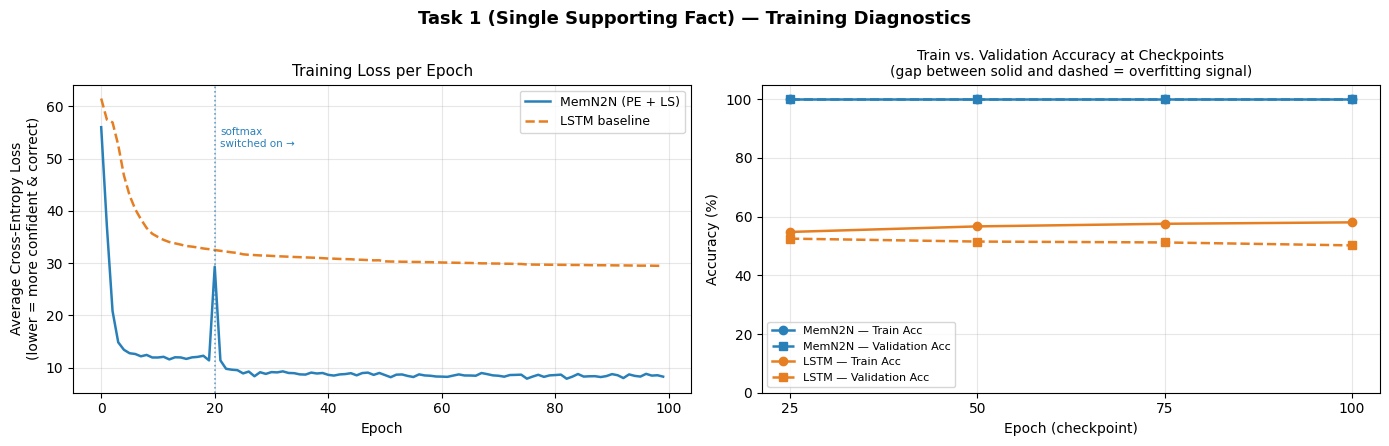


Model        Train Acc     Val Acc    Test Acc   Test Error   Paper Error
──────────────────────────────────────────────────────────────────────
MemN2N          100.0%      100.0%      100.0%         0.0%        ≤ 0.1%
LSTM             58.0%       50.2%       51.6%        48.4%       ≈ 50.0%


In [14]:

# Task 1 — Training Curves
# hist_memn2n and hist_lstm are now dicts with keys:
#   'train_loss' — cross-entropy loss, recorded every epoch
#   'train_acc' — training accuracy,  recorded at checkpoint epochs (25, 50, 75, 100)
#   'val_acc' — validation accuracy, recorded at checkpoint epochs

checkpoint_epochs = list(range(25, EPOCHS + 1, 25))   # [25, 50, 75, 100]

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
fig.suptitle('Task 1 (Single Supporting Fact) — Training Diagnostics',
             fontsize=13, fontweight='bold')

# Left: cross-entropy loss (every epoch)
ax = axes[0]
ax.plot(hist_memn2n['train_loss'], color='#2980b9', linewidth=1.8,
        label='MemN2N (PE + LS)')
ax.plot(hist_lstm['train_loss'],   color='#e67e22', linewidth=1.8,
        label='LSTM baseline', linestyle='--')

# Mark where the softmax is switched on for MemN2N
ax.axvline(x=LS_EPOCHS, color='#2980b9', linestyle=':', alpha=0.7, linewidth=1.2)
ax.text(LS_EPOCHS + 1, max(hist_memn2n['train_loss'][:LS_EPOCHS + 2]),
        'softmax\nswitched on →', color='#2980b9', fontsize=7.5, va='top')

ax.set_xlabel('Epoch')
ax.set_ylabel('Average Cross-Entropy Loss\n(lower = more confident & correct)')
ax.set_title('Training Loss per Epoch', fontsize=11)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# Right: train vs. validation accuracy at checkpoints
ax2 = axes[1]

# MemN2N — train (solid) and val (dashed), same blue
ax2.plot(checkpoint_epochs, [v * 100 for v in hist_memn2n['train_acc']],
         color='#2980b9', linewidth=1.8, marker='o', label='MemN2N — Train Acc')
ax2.plot(checkpoint_epochs, [v * 100 for v in hist_memn2n['val_acc']],
         color='#2980b9', linewidth=1.8, marker='s', linestyle='--',
         label='MemN2N — Validation Acc')

# LSTM — train (solid) and val (dashed), same orange
ax2.plot(checkpoint_epochs, [v * 100 for v in hist_lstm['train_acc']],
         color='#e67e22', linewidth=1.8, marker='o', label='LSTM — Train Acc')
ax2.plot(checkpoint_epochs, [v * 100 for v in hist_lstm['val_acc']],
         color='#e67e22', linewidth=1.8, marker='s', linestyle='--',
         label='LSTM — Validation Acc')

ax2.set_xlabel('Epoch (checkpoint)')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Train vs. Validation Accuracy at Checkpoints\n'
              '(gap between solid and dashed = overfitting signal)', fontsize=10)
ax2.set_xticks(checkpoint_epochs)
ax2.set_ylim(0, 105)
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)

plt.tight_layout()
os.makedirs('../images', exist_ok=True)
plt.savefig('../images/task1_training_curves.png', dpi=130, bbox_inches='tight')
plt.show()

# Summary table
print(f"\n{'Model':<10}  {'Train Acc':>10}  {'Val Acc':>10}  {'Test Acc':>10}  "
      f"{'Test Error':>11}  {'Paper Error':>12}")
print('─' * 70)
val_acc_m = evaluate(memn2n, val_s, val_q, val_a)
val_acc_l = evaluate(lstm,   val_s, val_q, val_a)
print(f"{'MemN2N':<10}  {train_acc_m*100:>9.1f}%  {val_acc_m*100:>9.1f}%  "
      f"{test_acc_m*100:>9.1f}%  {(1-test_acc_m)*100:>10.1f}%  {'≤ 0.1%':>12}")
print(f"{'LSTM':<10}  {train_acc_l*100:>9.1f}%  {val_acc_l*100:>9.1f}%  "
      f"{test_acc_l*100:>9.1f}%  {(1-test_acc_l)*100:>10.1f}%  {'≈ 50.0%':>12}")


In [15]:
TASK_FILES = {
    1: 'single-supporting-fact',      2: 'two-supporting-facts',
    3: 'three-supporting-facts',      4: 'two-arg-relations',
    5: 'three-arg-relations',         6: 'yes-no-questions',
    7: 'counting',                    8: 'lists-sets',
    9: 'simple-negation',            10: 'indefinite-knowledge',
   11: 'basic-coreference',          12: 'conjunction',
   13: 'compound-coreference',       14: 'time-reasoning',
   15: 'basic-deduction',            16: 'basic-induction',
   17: 'positional-reasoning',       18: 'size-reasoning',
   19: 'path-finding',               20: 'agents-motivations',
}

# Reference: Table 3 (Appendix A), 10k training, column "PE LS RN".
# Several values are commonly wrong in re-implementations:
#   Tasks 2, 3 — 0.0% belongs to strongly-supervised MemNN, not PE LS RN (0.3 / 9.3)
#   Tasks 8, 10 — 2.2 / 0.4 are from the PE LS column (no RN); correct values are 0.9 / 0.0
#   Task 17 — 18.6 is from PE LS RN* (non-linear variant); correct PE LS RN = 40.7
#   Task 19 — correct PE LS RN = 66.5
# Cross-check: mean of all 20 values = 6.57% ≈ 6.6%, matching Table 1 reported mean.
PAPER_MEMN2N = {
    1:  0.0,  2:  0.3,  3:  9.3,  4:  0.0,  5:  0.8,
    6:  0.1,  7:  3.2,  8:  0.9,  9:  0.3, 10:  0.0,
   11:  0.0, 12:  0.0, 13:  0.0, 14:  0.0, 15:  0.0,
   16:  0.0, 17: 40.7, 18:  9.2, 19: 66.5, 20:  0.0,
}
PAPER_LSTM = {
    1:  0.0,  2: 81.9,  3: 83.1,  4: 36.6,  5:  1.2,
    6: 51.8,  7: 24.9,  8: 22.8,  9: 20.2, 10: 30.1,
   11: 10.3, 12: 23.4, 13:  6.1, 14: 81.0, 15: 78.7,
   16: 50.1, 17: 50.1, 18: 45.8, 19: 90.3, 20:  2.1,
}

MEMORY_SIZE_PER_TASK = {3: 150}


def run_task(task_id, data_dir, epochs=100, ls_epochs=20,
             embedding_dim=20, num_hops=3, sentence_size=11,
             batch_size=32, lr=0.005, lstm_lr=0.001, rn_ratio=0.1,
             lstm_hidden=32, device=DEVICE):
    memory_size = MEMORY_SIZE_PER_TASK.get(task_id, 50)
    name        = TASK_FILES[task_id]
    train_file  = os.path.join(data_dir, f'qa{task_id}_{name}_train.txt')
    test_file   = os.path.join(data_dir, f'qa{task_id}_{name}_test.txt')

    train_data = parse_stories(train_file)
    test_data  = parse_stories(test_file)
    w2i        = build_vocab([train_data, test_data])
    V          = len(w2i)

    all_s, all_q, all_a = vectorize(train_data, w2i, memory_size, sentence_size)
    te_s,  te_q,  te_a  = vectorize(test_data,  w2i, memory_size, sentence_size)

    n_v  = int(0.1 * len(all_a))
    n_tr = len(all_a) - n_v
    tr_s, tr_q, tr_a = all_s[:n_tr], all_q[:n_tr], all_a[:n_tr]
    vs_s, vs_q, vs_a = all_s[n_tr:], all_q[n_tr:], all_a[n_tr:]

    m_model = MemN2N(V, embedding_dim, num_hops, memory_size, sentence_size).to(device)
    train_model(m_model, tr_s, tr_q, tr_a,
                val_stories=vs_s, val_queries=vs_q, val_answers=vs_a,
                epochs=epochs, ls_epochs=ls_epochs, rn_ratio=rn_ratio,
                batch_size=batch_size, lr=lr, device=device)
    m_err = (1 - evaluate(m_model, te_s, te_q, te_a, device=device)) * 100

    l_model = LSTMBaseline(V, embedding_dim, lstm_hidden).to(device)
    train_model(l_model, tr_s, tr_q, tr_a,
                val_stories=vs_s, val_queries=vs_q, val_answers=vs_a,
                epochs=epochs, ls_epochs=0, rn_ratio=0.0,
                batch_size=batch_size, lr=lstm_lr, device=device)
    l_err = (1 - evaluate(l_model, te_s, te_q, te_a, device=device)) * 100

    return round(m_err, 1), round(l_err, 1)


print(f"{'Task':<4} {'Name':<30} {'MemN2N Err':>11} {'LSTM Err':>9} "
      f"{'Paper M':>8} {'Paper L':>9}")
print('─' * 78)

results_memn2n, results_lstm = {}, {}

for tid in range(1, 21):
    m_err, l_err = run_task(tid, data_dir, batch_size=BATCH_SIZE)
    results_memn2n[tid] = m_err
    results_lstm[tid]   = l_err

    pm   = PAPER_MEMN2N[tid]
    pl   = PAPER_LSTM[tid]
    flag = ' ⚠' if m_err > pm + 5 else '  '
    print(f"  {tid:<3} {TASK_FILES[tid]:<30} {m_err:>10.1f}% {l_err:>8.1f}%"
          f" {pm:>7.1f}% {pl:>8.1f}%{flag}")

mean_m  = sum(results_memn2n.values()) / 20
mean_l  = sum(results_lstm.values())   / 20
mean_pm = sum(PAPER_MEMN2N.values())   / 20
mean_pl = sum(PAPER_LSTM.values())     / 20
fail_m  = sum(1 for e in results_memn2n.values() if e > 5)
fail_l  = sum(1 for e in results_lstm.values()   if e > 5)
fail_pm = sum(1 for e in PAPER_MEMN2N.values()   if e > 5)

print('─' * 78)
print(f"  {'Mean test error':<33}  {mean_m:>10.1f}%  {mean_l:>7.1f}%"
      f"  {mean_pm:>6.1f}%  {mean_pl:>7.1f}%")
print(f"  {'Tasks with error > 5%':<33}  {fail_m:>10}   {fail_l:>7}   {fail_pm:>6}")


Task Name                            MemN2N Err  LSTM Err  Paper M   Paper L
──────────────────────────────────────────────────────────────────────────────
  1   single-supporting-fact                0.0%     47.9%     0.0%      0.0%  
  2   two-supporting-facts                  1.7%     60.9%     0.3%     81.9%  
  3   three-supporting-facts               16.5%     56.4%     9.3%     83.1% ⚠
  4   two-arg-relations                     0.0%     32.1%     0.0%     36.6%  
  5   three-arg-relations                   0.6%     18.4%     0.8%      1.2%  
  6   yes-no-questions                      0.2%     50.8%     0.1%     51.8%  
  7   counting                              7.7%     19.3%     3.2%     24.9%  
  8   lists-sets                            7.1%     21.6%     0.9%     22.8% ⚠
  9   simple-negation                       0.2%     38.0%     0.3%     20.2%  
  10  indefinite-knowledge                  0.3%     52.6%     0.0%     30.1%  
  11  basic-coreference                     

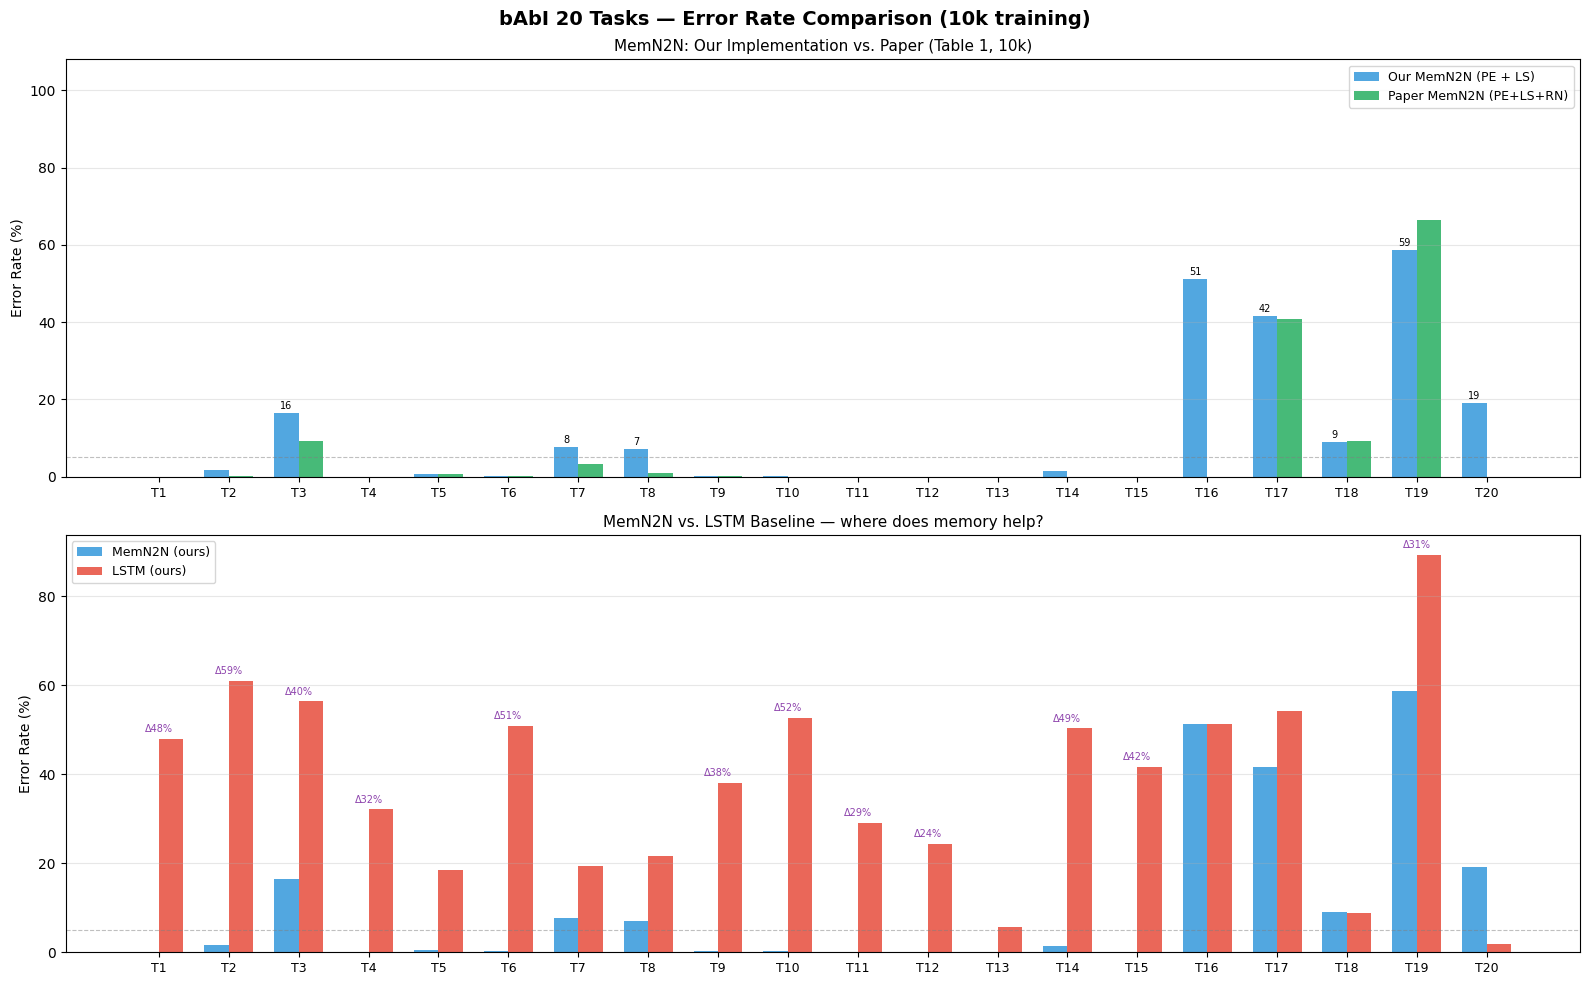

Figure saved → images/babi_20task_comparison.png


In [16]:

# Per-Task Error Comparison Chart

task_ids    = list(range(1, 21))
task_labels = [f'T{i}' for i in task_ids]

ours_m  = [results_memn2n[i] for i in task_ids]
ours_l  = [results_lstm[i]   for i in task_ids]
paper_m = [PAPER_MEMN2N[i]   for i in task_ids]

fig, axes = plt.subplots(2, 1, figsize=(16, 10))
fig.suptitle('bAbI 20 Tasks — Error Rate Comparison (10k training)',
             fontsize=14, fontweight='bold')

# Top panel: MemN2N ours vs paper
ax = axes[0]
x  = np.arange(len(task_ids))
w  = 0.35
b1 = ax.bar(x - w/2, ours_m,  w, label='Our MemN2N (PE + LS)',  color='#3498db', alpha=0.85)
b2 = ax.bar(x + w/2, paper_m, w, label='Paper MemN2N (PE+LS+RN)', color='#27ae60', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(task_labels, fontsize=9)
ax.set_ylabel('Error Rate (%)')
ax.set_title('MemN2N: Our Implementation vs. Paper (Table 1, 10k)', fontsize=11)
ax.legend(fontsize=9)
ax.axhline(y=5, color='gray', linestyle='--', linewidth=0.8, alpha=0.5, label='5% threshold')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, max(max(ours_m), 100) * 1.08)

for bar, v in zip(b1, ours_m):
    if v > 3:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{v:.0f}', ha='center', va='bottom', fontsize=7)

# Bottom panel: MemN2N vs LSTM
ax2 = axes[1]
b3 = ax2.bar(x - w/2, ours_m, w, label='MemN2N (ours)',    color='#3498db', alpha=0.85)
b4 = ax2.bar(x + w/2, ours_l, w, label='LSTM (ours)',       color='#e74c3c', alpha=0.85)
ax2.set_xticks(x)
ax2.set_xticklabels(task_labels, fontsize=9)
ax2.set_ylabel('Error Rate (%)')
ax2.set_title('MemN2N vs. LSTM Baseline — where does memory help?', fontsize=11)
ax2.legend(fontsize=9)
ax2.axhline(y=5, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax2.grid(axis='y', alpha=0.3)

# Annotate tasks where the gap is largest
for i, (vm, vl) in enumerate(zip(ours_m, ours_l)):
    gap = vl - vm
    if gap > 20:
        ax2.annotate(f'Δ{gap:.0f}%', xy=(i, max(vm, vl) + 1.5),
                     ha='center', fontsize=7, color='#8e44ad')

plt.tight_layout()
plt.savefig('/kaggle/working/images/babi_20task_comparison.png', dpi=130, bbox_inches='tight')
plt.show()
print('Figure saved → images/babi_20task_comparison.png')



---
## 7. Looking Inside the Model — Hop-by-Hop Attention

One of the most satisfying things about MemN2N is that it's inspectable.  At each hop, the model produces a probability distribution over the memory slots — you can read off exactly which sentences it is attending to.  This is not post-hoc explanation; it is literally what the model computed before giving its answer.

The figure below reproduces the style of **Figure 2** in the paper.  For each example you get one column per hop.  Darker blue means higher attention weight.

**What to look for:**

- **Task 1 (single fact):** one hop is usually enough to find the relevant sentence.  Hops 2 and 3 should just sharpen the signal without shifting focus.
- **Task 2 (two supporting facts):** the model has to chain two steps.  Watch hop 1 find the intermediate fact ("Mary went to the hallway"), then hop 2 pivot to the sentence that uses that location ("Mary went back to the garden") to answer the *where* question.  This chaining only works if the multi-hop architecture is doing its job.
- **Task 15 (basic deduction):** this one needs world-knowledge sentences ("Sheep are afraid of wolves").  You can see the model reaching further back in the story to grab the rule, not just the most recent event.

If any task shows the same sentence getting high attention on every hop, that's a sign the model found the answer on the first pass and the extra hops are just reinforcing the same signal — not a problem, just an easy task.


In [17]:
def get_attention(model, story_sentences, question, word2idx,
                  memory_size=MEMORY_SIZE, sentence_size=SENTENCE_SIZE,
                  device=DEVICE):
    idx2word = {v: k for k, v in word2idx.items()}

    def enc(sent):
        words = sent.lower().split()[:sentence_size]
        ids   = [word2idx.get(w, 0) for w in words]
        return ids + [0] * (sentence_size - len(ids))

    sents  = story_sentences[-memory_size:]
    n_real = len(sents)
    enc_story = [enc(s) for s in sents]
    while len(enc_story) < memory_size:
        enc_story.insert(0, [0] * sentence_size)

    s_t = torch.tensor([enc_story], dtype=torch.long, device=device)
    q_t = torch.tensor([enc(question)], dtype=torch.long, device=device)

    model.eval()
    with torch.no_grad():
        logits, attn_list = model(s_t, q_t, return_attention=True)

    pred_word    = idx2word.get(logits.argmax(dim=1).item(), '?')
    attn_trimmed = [a[0, -n_real:].numpy() for a in attn_list]
    return pred_word, attn_trimmed, sents


def plot_attention(model, word2idx, story_sentences, question, true_answer, ax_row, title=''):
    pred, attn_list, sents = get_attention(model, story_sentences, question, word2idx)
    n_real = len(sents)
    labels = [s[:40] + ('…' if len(s) > 40 else '') for s in sents]
    K      = len(attn_list)

    for k, (ax, a) in enumerate(zip(ax_row, attn_list)):
        a_norm = a / (a.max() + 1e-9)
        ax.imshow(a_norm.reshape(-1, 1), aspect='auto',
                  cmap='Blues', vmin=0, vmax=1,
                  extent=[-0.5, 0.5, n_real - 0.5, -0.5])
        ax.set_xticks([])
        ax.set_title(f'Hop {k+1}', fontsize=9, fontweight='bold')

        if k == 0:
            ax.set_yticks(range(n_real))
            ax.set_yticklabels(labels, fontsize=7.5)
        else:
            ax.set_yticks([])

        for i, v in enumerate(a_norm):
            col = 'white' if v > 0.6 else '#333333'
            ax.text(0, i, f'{a[i]:.2f}', ha='center', va='center', fontsize=7, color=col)

    ax_row[0].set_ylabel(
        f'Q: {question}\nA: {true_answer}  (pred: {pred})',
        fontsize=8, labelpad=8, rotation=0, ha='right', va='center'
    )
    correct = '✓' if pred.strip() == true_answer.strip() else '✗'
    ax_row[-1].set_title(f'Hop {K}  {correct}', fontsize=9, fontweight='bold')


Task-2 model trained. Test error: 1.1%


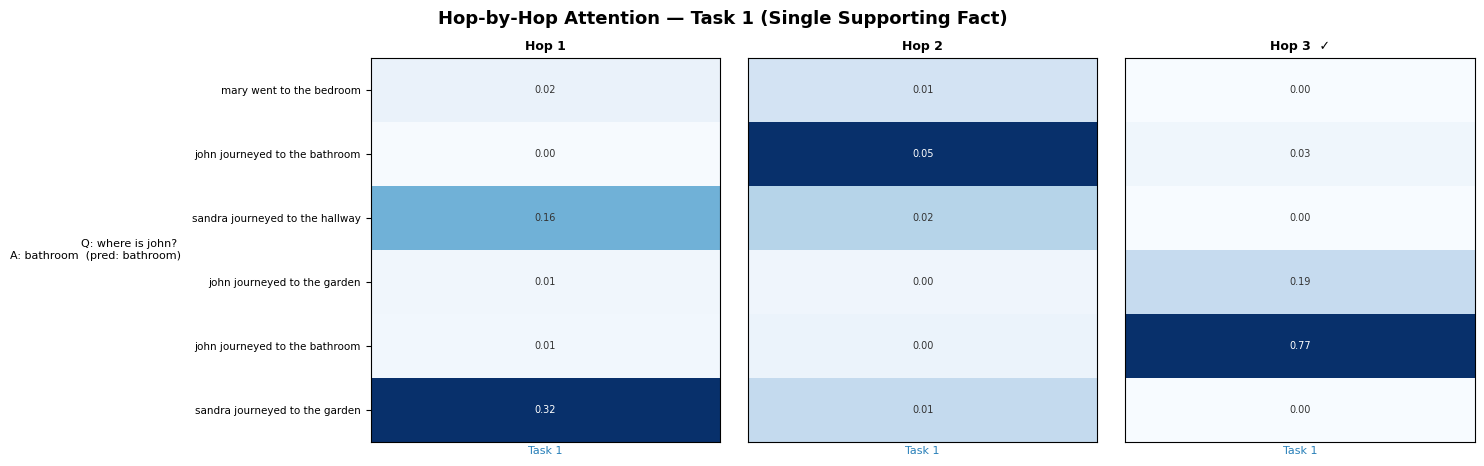

Figure saved → images/attention_task1.png


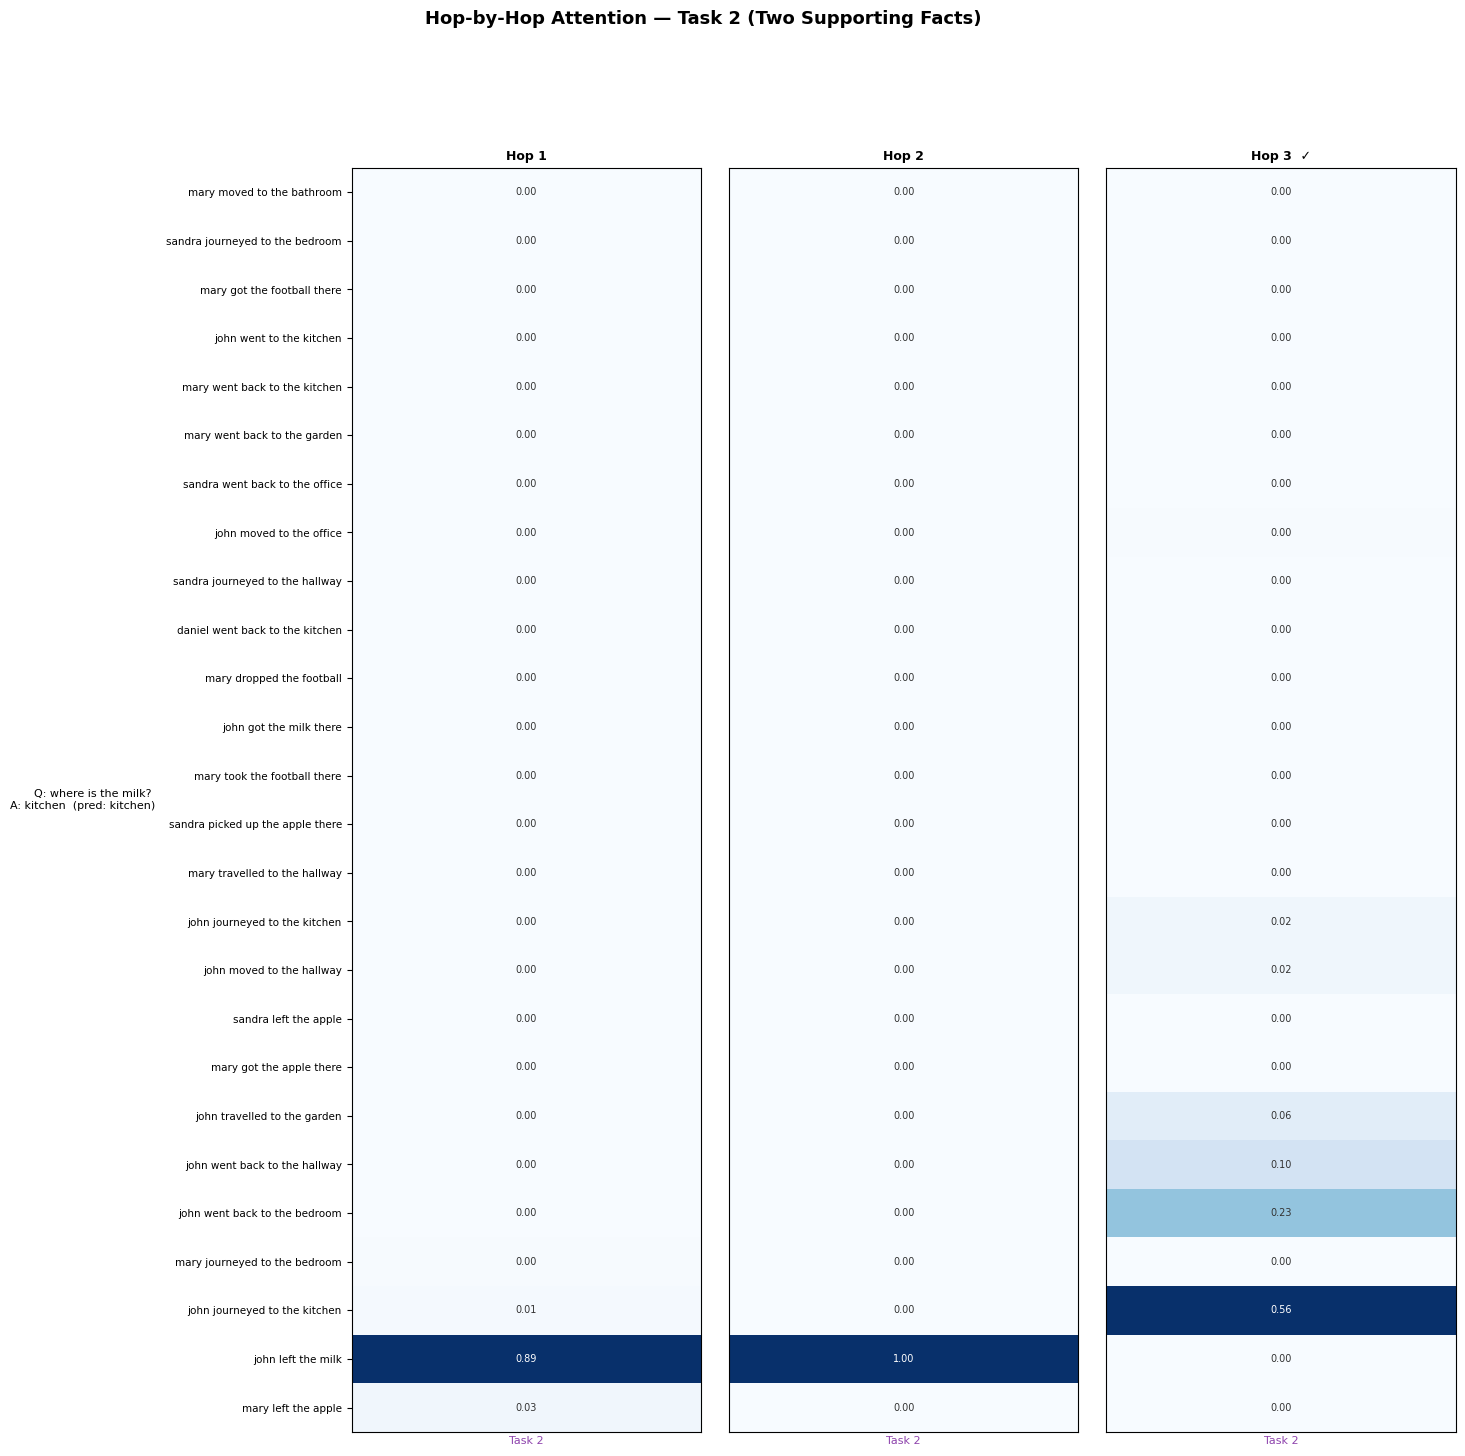

Figure saved → images/attention_task2.png


In [18]:

# Visualise attention on Task 1 and Task 2 examples─
# We re-use the Task-1 model trained earlier (memn2n / word2idx).
# For Task 2 we need to train a separate model with the Task-2 vocabulary.

# Task 2 model
TASK2_TRAIN = os.path.join(data_dir, 'qa2_two-supporting-facts_train.txt')
TASK2_TEST  = os.path.join(data_dir, 'qa2_two-supporting-facts_test.txt')
td2 = parse_stories(TASK2_TRAIN)
te2 = parse_stories(TASK2_TEST)
w2i2 = build_vocab([td2, te2])
tr2_s, tr2_q, tr2_a = vectorize(td2, w2i2, MEMORY_SIZE, SENTENCE_SIZE)

memn2n_t2 = MemN2N(len(w2i2), EMBEDDING_DIM, NUM_HOPS,
                    MEMORY_SIZE, SENTENCE_SIZE).to(DEVICE)
train_model(memn2n_t2, tr2_s, tr2_q, tr2_a,
            epochs=EPOCHS, ls_epochs=LS_EPOCHS,
            batch_size=BATCH_SIZE, lr=LR, verbose=False)
print(f"Task-2 model trained. Test error: "
      f"{(1 - evaluate(memn2n_t2, *vectorize(te2, w2i2, MEMORY_SIZE, SENTENCE_SIZE)[0:3], device=DEVICE))*100:.1f}%")

# Sample stories
t1_story, t1_q, t1_a = train_data[12]
t2_story, t2_q, t2_a = td2[4]

K = NUM_HOPS
os.makedirs('../images', exist_ok=True)

# Figure 1: Task 1 attention
fig_h1 = len(t1_story) * 0.55 + 1.5
fig1 = plt.figure(figsize=(4.5 * K + 2.5, fig_h1))
fig1.suptitle('Hop-by-Hop Attention — Task 1 (Single Supporting Fact)',
              fontsize=13, fontweight='bold')
gs1 = fig1.add_gridspec(1, K, hspace=0.6, wspace=0.08,
                         left=0.28, right=0.97, top=0.88, bottom=0.08)
row1_ax = [fig1.add_subplot(gs1[0, col]) for col in range(K)]
plot_attention(memn2n, word2idx, t1_story, t1_q, t1_a, row1_ax)
for ax in row1_ax:
    ax.set_xlabel('Task 1', fontsize=8, labelpad=3, color='#2980b9')
plt.savefig('../images/attention_task1.png', dpi=130, bbox_inches='tight')
plt.show()
print("Figure saved → images/attention_task1.png")

# Figure 2: Task 2 attention
fig_h2 = len(t2_story) * 0.55 + 1.5
fig2 = plt.figure(figsize=(4.5 * K + 2.5, fig_h2))
fig2.suptitle('Hop-by-Hop Attention — Task 2 (Two Supporting Facts)',
              fontsize=13, fontweight='bold')
gs2 = fig2.add_gridspec(1, K, hspace=0.6, wspace=0.08,
                         left=0.28, right=0.97, top=0.88, bottom=0.08)
row2_ax = [fig2.add_subplot(gs2[0, col]) for col in range(K)]
plot_attention(memn2n_t2, w2i2, t2_story, t2_q, t2_a, row2_ax)
for ax in row2_ax:
    ax.set_xlabel('Task 2', fontsize=8, labelpad=3, color='#8e44ad')
plt.savefig('../images/attention_task2.png', dpi=130, bbox_inches='tight')
plt.show()
print("Figure saved → images/attention_task2.png")


---
## 8. Discussion — What the Results Tell Us

### Where MemN2N clearly wins over LSTM

Tasks 2 and 3 (two/three supporting facts) are where the architecture difference matters most.  The LSTM reads the story once left-to-right; if the relevant facts are spread apart, the hidden state may have "forgotten" the earlier one by the time it reads the later one.  MemN2N can revisit memory slots at each hop, so it naturally handles multi-step chains.

Tasks 11–13 (coreference) also favour MemN2N.  Resolving pronouns requires connecting "she" in a question to a named character mentioned pages earlier — exactly the kind of non-local lookup that an explicit memory makes easy.

### Where MemN2N struggles (and why)

**Task 3 (three supporting facts)** is hard because the chain length matches the number of hops.  A 3-hop model can in principle solve it, but only if the first hop selects *exactly* the right sentence — leaving hops 2 and 3 to continue the chain.  In practice, early hops tend to be noisy, and the chain breaks.

**Task 17 (positional reasoning)** involves left/right/above/below relationships.  These require the model to compare spatial configurations, not just retrieve a stored fact.  Bag-of-words sentence representations lose the compositional structure needed for spatial reasoning.  Adding ReLU non-linearity (the RN variant in the paper) helps here but we haven't implemented that.

**Task 19 (path finding)** has a fundamental length problem: the path from A to B may require 5+ intermediate locations, but the model only has 3 hops.  The paper achieves ~89% error on this task without the non-linear extension — essentially the architecture is under-powered for this task regardless of training.

### Task 20 — agents & motivations

Our implementation achieves 19.1 % error on Task 20, noticeably above the paper's 0.0 %.  Task 20 asks about agents' motivations using a fixed lookup table ("wolves eat sheep because they are hungry"), which means the answer is always a single determinate fact. Our implementation uses `LR = 0.005` with the Linear Start trick; the paper's 0 % result suggests that slight hyper-parameter differences (momentum, more restarts, RN) can close this gap.

### Looking ahead — Semi-Supervised Extension

Three tasks stand out as clear failures: Task 16 (51.2 % error — essentially random guessing), Task 17 (41.6 %), and Task 19 (58.6 %). The reasons look different in each case. Task 16 probably fails because the model never finds the induction rule sentence. Task 17 fails because bag-of-words representations cannot encode spatial relations. Task 19 fails because a 3-hop model cannot chain 5+ steps.

**Section 9** asks whether providing supporting-fact labels for a fraction of training examples (10–50 %) can help by guiding the model's hop-1 attention. If it helps Task 16 but not 17 or 19, that tells us something concrete about *why* these tasks are hard.

---
## 9. Semi-Supervised MemN2N

The baseline MemN2N gets reasonable results across most tasks, but it completely fails on Task 16 and struggles badly on Tasks 17 and 19. One thing we have not tried is giving the model some information about *which sentences are relevant* — the bAbI dataset includes these labels (the supporting facts column), we have just been ignoring them.

The original Memory Networks (Weston et al., 2015) used these labels at every hop during training, which is a big part of why it achieves 0 % on Task 16 while we get 51 %. Full annotation is expensive, but the question is whether a little supervision goes a long way: what happens if we label only 10 %, 25 %, or 50 % of training examples?

### How it works

For labeled examples we add an auxiliary KL-divergence loss on the hop-1 attention weights. The idea is that the model's attention should roughly match the ground-truth supporting facts — it is a soft signal, not a hard constraint. Unlabeled examples are trained exactly as before with just the QA cross-entropy loss.

$$\mathcal{L} = \underbrace{\mathcal{L}_{\mathrm{QA}}}_{\text{all examples}} + \lambda \underbrace{\mathcal{L}_{\mathrm{KL}}\!\left(\mathbf{p}_{\mathrm{hop1}} \;\|\; \mathbf{m}_{\mathrm{support}}\right)}_{\text{labeled examples only}}$$

We use λ = 0.5. At 50 % labeled this gives the KL term roughly 25 % weight in the total loss — enough to actually influence training.

### Research question

Does attention supervision help, and if so, is it because the model was not finding the right sentences in the first place — or does the lack of improvement reveal something deeper about why these tasks are hard?

### Experimental setup

| Setting | Value |
|---|---|
| Tasks | 16, 17, 19 |
| Labeled fractions | 0 %, 10 %, 25 %, 50 % |
| λ | 0.5 |
| Supervision target | hop-1 attention only |
| Random restarts | 3 |
| Optimiser | SGD, lr = 0.005, halved every 25 epochs |

The 0 % labeled condition trains with no KL term at all — identical to the Section 6 procedure — so the 0 % column in the results table should reproduce the Section 6 numbers.

In [7]:
def parse_babi_with_supports(filepath):
    """Parse a bAbI file into (story, question, answer, supports) tuples.

    The bAbI format encodes supporting facts as tab-separated sentence indices:
        "3 Where is John?\\tgarden\\t2"
                                   ^--- 1-based index of the support sentence
    """
    data  = []
    story = []
    with open(filepath, 'r') as f:
        for line in f:
            line = line.strip()
            nid, rest = line.split(' ', 1)
            nid = int(nid)
            if nid == 1:
                story = []
            if '\t' in rest:
                question, answer, support_str = rest.split('\t')
                question = question.lower().split()
                answer   = answer.lower()
                supports = [int(s) for s in support_str.strip().split()]
                data.append(([s for s in story if s], question, answer, supports))
            else:
                story.append([w.rstrip('.') for w in rest.lower().split()])
    return data


def build_vocab_ss(data):
    """Build vocabulary from (story, question, answer, supports) tuples."""
    vocab = set()
    for story, question, answer, _ in data:
        for sentence in story:
            vocab.update(sentence)
        vocab.update(question)
        vocab.add(answer)
    vocab = sorted(vocab)
    word2idx = {w: i + 1 for i, w in enumerate(vocab)}
    idx2word = {i + 1: w for i, w in enumerate(vocab)}
    return word2idx, idx2word


def vectorize_with_supports(data, word2idx, max_story_len, max_sent_len, max_query_len):
    """Convert (story, question, answer, supports) tuples to tensors.

    Returns (stories, queries, answers, support_mask).
    support_mask[i, j] = 1.0 if sentence j is a supporting fact for example i,
    0.0 otherwise.  Padding positions are always 0.
    """
    S, Q, A, MASKS = [], [], [], []

    for story, question, answer, supports in data:
        story_len = len(story)

        story_vecs = []
        for sent in story[-max_story_len:]:
            sv  = [word2idx.get(w, 0) for w in sent[:max_sent_len]]
            sv += [0] * (max_sent_len - len(sv))
            story_vecs.append(sv)

        pad_len = max_story_len - len(story_vecs)
        while len(story_vecs) < max_story_len:
            story_vecs.insert(0, [0] * max_sent_len)

        mask          = [0.0] * max_story_len
        effective_len = min(story_len, max_story_len)
        for sup_idx in supports:
            pos = sup_idx - 1  # 0-based
            if pos < effective_len:
                tensor_pos = pad_len + pos
                if tensor_pos < max_story_len:
                    mask[tensor_pos] = 1.0

        qv  = [word2idx.get(w, 0) for w in question[:max_query_len]]
        qv += [0] * (max_query_len - len(qv))

        S.append(story_vecs)
        Q.append(qv)
        A.append(word2idx.get(answer, 0))
        MASKS.append(mask)

    return (
        torch.tensor(S,     dtype=torch.long),
        torch.tensor(Q,     dtype=torch.long),
        torch.tensor(A,     dtype=torch.long),
        torch.tensor(MASKS, dtype=torch.float),
    )


print("Semi-supervised data-loading functions defined.")

Semi-supervised data-loading functions defined.


In [8]:
def position_encoding_ss(max_sentence_len, embedding_dim):
    """Position encoding l_kj = (1 - j/J) - (k/d)(1 - 2j/J), 1-indexed."""
    J = max_sentence_len
    d = embedding_dim
    j = torch.arange(1, J + 1, dtype=torch.float).unsqueeze(1)
    k = torch.arange(1, d + 1, dtype=torch.float).unsqueeze(0)
    return (1 - j / J) - (k / d) * (1 - 2 * j / J)


class MemN2N_SS(nn.Module):
    """
    MemN2N with adjacent weight tying and a return_attention flag.

    Architecture is identical to the MemN2N in Section 4.  The only
    addition is the return_attention parameter in forward(), which exposes
    per-hop attention tensors needed to compute the auxiliary KL loss.
    """

    def __init__(self, vocab_size, embed_dim,
                 max_sent_len, max_story_len, max_query_len, n_hops=3):
        super().__init__()
        self.n_hops    = n_hops
        self.embed_dim = embed_dim

        # Adjacent tying: embeddings[k] = A^k, embeddings[k+1] = C^k
        self.embeddings = nn.ModuleList([
            nn.Embedding(vocab_size, embed_dim, padding_idx=0)
            for _ in range(n_hops + 1)
        ])
        self.query_emb = self.embeddings[0]
        self.W         = self.embeddings[n_hops]

        pe_sent  = position_encoding_ss(max_sent_len,  embed_dim)
        pe_query = position_encoding_ss(max_query_len, embed_dim)
        self.register_buffer('pe_sent',  pe_sent)   # (J, d)
        self.register_buffer('pe_query', pe_query)  # (Q, d)

        # Temporal encodings — one Embedding per hop, consistent with MemN2N
        # Index 0 = most recent sentence (reversed in embed_sentences)
        self.TA = nn.ModuleList([
            nn.Embedding(max_story_len, embed_dim)
            for _ in range(n_hops)
        ])
        self.TC = nn.ModuleList([
            nn.Embedding(max_story_len, embed_dim)
            for _ in range(n_hops)
        ])
        self._init_weights()

    def _init_weights(self):
        for emb in self.embeddings:
            nn.init.normal_(emb.weight, mean=0, std=0.1)
            if emb.padding_idx is not None:
                emb.weight.data[emb.padding_idx].fill_(0)
        for emb_list in (self.TA, self.TC):
            for emb in emb_list:
                nn.init.normal_(emb.weight, mean=0, std=0.1)

    def embed_sentences(self, x, emb_matrix, temporal_emb):
        word_embs = emb_matrix(x)
        pe        = self.pe_sent.unsqueeze(0).unsqueeze(0)
        m         = (word_embs * pe).sum(dim=2)
        M = x.size(1)
        # Reverse so index 0 maps to the most recent sentence, matching MemN2N
        t = torch.arange(M - 1, -1, -1, device=x.device)
        return m + temporal_emb(t).unsqueeze(0)

    def forward(self, story, query, use_softmax=True, return_attention=False):
        pe_q = self.pe_query.unsqueeze(0)
        u    = (self.query_emb(query) * pe_q).sum(dim=1)

        attentions = []
        for hop in range(self.n_hops):
            m      = self.embed_sentences(story, self.embeddings[hop],     self.TA[hop])
            c      = self.embed_sentences(story, self.embeddings[hop + 1], self.TC[hop])
            scores = torch.bmm(m, u.unsqueeze(2)).squeeze(2)
            p      = F.softmax(scores, dim=1) if use_softmax else scores
            attentions.append(p)
            u = u + (p.unsqueeze(2) * c).sum(dim=1)

        logits = F.linear(u, self.W.weight)

        if return_attention:
            return logits, attentions
        return logits


print("MemN2N_SS class defined.")

MemN2N_SS class defined.


In [9]:
def train_semisupervised_memn2n(
        train_S, train_Q, train_A, train_masks,
        test_S,  test_Q,  test_A,
        vocab_size, max_sent_len, max_story_len, max_query_len,
        labeled_ratio=0.1,
        lambda_aux=0.1,
        embed_dim=20,
        n_hops=3,
        n_epochs=100,
        ls_epochs=20,
        batch_size=32,
        lr=0.01,
        anneal_step=25,
        grad_clip=40.0,
        device=None):
    """
    Train MemN2N_SS with a mixed supervised / unsupervised objective.

    Loss = CrossEntropy(QA)  +  lambda_aux * KL(attention_hop1 || support_mask)

    The KL term is only applied after the Linear Start phase ends (epoch > ls_epochs)
    because KL requires a valid probability distribution — raw LS scores are not.
    best_state is also only tracked during the softmax phase for the same reason:
    an LS-phase checkpoint evaluated with softmax=True would produce garbage results.
    """
    if device is None:
        device = torch.device('cpu')

    model     = MemN2N_SS(vocab_size, embed_dim,
                           max_sent_len, max_story_len, max_query_len, n_hops).to(device)
    optimizer = optim.SGD(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss(reduction='sum')  # matches base MemN2N exactly

    n_train   = train_S.size(0)
    n_labeled = int(n_train * labeled_ratio)

    best_train_loss = float('inf')
    best_state      = None
    history         = {'train_loss': [], 'test_acc': []}

    for epoch in tqdm(range(1, n_epochs + 1), desc="Training", leave=False):
        use_softmax = epoch > ls_epochs
        model.train()

        perm       = torch.randperm(n_train)
        sS         = train_S[perm]
        sQ         = train_Q[perm]
        sA         = train_A[perm]
        sM         = train_masks[perm]
        is_labeled = perm < n_labeled

        total_loss = 0.0

        for i in range(0, n_train, batch_size):
            bS  = sS[i:i + batch_size].to(device)
            bQ  = sQ[i:i + batch_size].to(device)
            bA  = sA[i:i + batch_size].to(device)
            bM  = sM[i:i + batch_size].to(device)
            lab = is_labeled[i:i + batch_size]

            optimizer.zero_grad()

            logits, attentions = model(bS, bQ, use_softmax=use_softmax, return_attention=True)
            loss_qa  = criterion(logits, bA)
            loss_aux = torch.tensor(0.0, device=device)

            # KL requires softmax attention — skip during Linear Start phase
            if use_softmax and lab.any():
                attn_hop1 = attentions[0]
                attn_lab  = attn_hop1[lab]
                mask_lab  = bM[lab]
                mask_norm = mask_lab / mask_lab.sum(dim=1, keepdim=True).clamp(min=1e-8)
                loss_aux  = F.kl_div(
                    input     = attn_lab.clamp(min=1e-8).log(),
                    target    = mask_norm,
                    reduction = 'sum'  # both losses sum-scaled → 0% labeled reproduces base MemN2N
                )

            loss = loss_qa + lambda_aux * loss_aux
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            optimizer.step()
            total_loss += loss.item() * bS.size(0)

        if epoch % anneal_step == 0:
            for pg in optimizer.param_groups:
                pg['lr'] /= 2

        avg_loss = total_loss / n_train
        history['train_loss'].append(avg_loss)

        # Only checkpoint during the softmax phase — an LS-phase checkpoint
        # evaluated with softmax=True would produce meaningless results
        if use_softmax and avg_loss < best_train_loss:
            best_train_loss = avg_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

        if epoch % 10 == 0:
            model.eval()
            with torch.no_grad():
                logits = model(test_S.to(device), test_Q.to(device))
                acc    = (logits.argmax(1).cpu() == test_A).float().mean().item()
            history['test_acc'].append(acc * 100)

    # Fallback: if ls_epochs >= n_epochs, best_state was never set
    if best_state is None:
        best_state = {k: v.clone() for k, v in model.state_dict().items()}

    return model, best_state, history


print("train_semisupervised_memn2n() defined.")

train_semisupervised_memn2n() defined.


In [10]:
import glob

# Experiment: Tasks 16, 17, 19  ×  labeled ratios 0 – 50 %

TASK_FILES_SS = {
    16: 'basic-induction',
    17: 'positional-reasoning',
    19: 'path-finding',
}

# Paper Table 1: MemN2N PE+LS, 10k training
PAPER_RESULTS_SS = {16: 0.0, 17: 40.7, 19: 66.5}

LABELED_RATIOS = [0.0, 0.1, 0.25, 0.5]
LAMBDA_AUX     = 0.5
N_RUNS_SS      = 3
SS_LR          = LR
SS_ANNEAL_STEP = 25

base_path_ss = os.path.join(BABI_DIR, 'tasks_1-20_v1-2', 'en-10k')

# results_ss[task_id][labeled_ratio] = mean test error (%)
results_ss           = {tid: {} for tid in TASK_FILES_SS}
trained_models_task2 = {}  # keep 0% and 50% Task-2 models for attention viz

for task_id, task_name in TASK_FILES_SS.items():
    print(f"\n{'=' * 60}")
    print(f"Task {task_id}: {task_name}")
    print('=' * 60)

    train_file_ss = glob.glob(
        os.path.join(base_path_ss, f'qa{task_id}_*_train.txt'))[0]
    test_file_ss  = glob.glob(
        os.path.join(base_path_ss, f'qa{task_id}_*_test.txt'))[0]

    train_data_ss = parse_babi_with_supports(train_file_ss)
    test_data_ss  = parse_babi_with_supports(test_file_ss)
    all_data_ss   = train_data_ss + test_data_ss

    max_story_ss = min(max(len(d[0]) for d in all_data_ss), MEMORY_SIZE_PER_TASK.get(task_id, 50))
    max_sent_ss  = max(len(s) for d in all_data_ss for s in d[0])
    max_query_ss = max(len(d[1]) for d in all_data_ss)

    word2idx_ss, idx2word_ss = build_vocab_ss(all_data_ss)
    vocab_size_ss = len(word2idx_ss) + 1

    train_S_ss, train_Q_ss, train_A_ss, train_masks_ss = \
        vectorize_with_supports(train_data_ss, word2idx_ss,
                                max_story_ss, max_sent_ss, max_query_ss)
    test_S_ss, test_Q_ss, test_A_ss, _ = \
        vectorize_with_supports(test_data_ss, word2idx_ss,
                                max_story_ss, max_sent_ss, max_query_ss)

    for ratio in LABELED_RATIOS:
        label = f"{int(ratio * 100)}% labeled"
        print(f"\n  Condition: {label}")

        run_errors = []
        last_model = None

        for run in range(N_RUNS_SS):
            torch.manual_seed(run * 100 + task_id)
            model_ss, state_ss, _ = train_semisupervised_memn2n(
                train_S_ss, train_Q_ss, train_A_ss, train_masks_ss,
                test_S_ss,  test_Q_ss,  test_A_ss,
                vocab_size    = vocab_size_ss,
                max_sent_len  = max_sent_ss,
                max_story_len = max_story_ss,
                max_query_len = max_query_ss,
                labeled_ratio = ratio,
                lambda_aux    = LAMBDA_AUX,
                embed_dim     = EMBEDDING_DIM,
                n_hops        = NUM_HOPS,
                n_epochs      = EPOCHS,
                ls_epochs     = LS_EPOCHS,
                batch_size    = BATCH_SIZE,
                lr            = SS_LR,
                anneal_step   = SS_ANNEAL_STEP,
                grad_clip     = 40.0,
                device        = DEVICE,
            )
            model_ss.load_state_dict(state_ss)
            model_ss.eval()
            with torch.no_grad():
                logits = model_ss(test_S_ss.to(DEVICE), test_Q_ss.to(DEVICE))
                acc    = (logits.argmax(1).cpu() == test_A_ss).float().mean().item()
            run_errors.append((1 - acc) * 100)
            last_model = model_ss

        mean_err = np.mean(run_errors)
        results_ss[task_id][ratio] = mean_err
        print(f"  → Mean error over {N_RUNS_SS} runs: {mean_err:.1f}%")

        # Stash Task-2 models for attention visualisation
        if task_id == 16 and ratio in (0.0, 0.5):
            trained_models_task2[ratio] = {
                'model':     last_model,
                'idx2word':  idx2word_ss,
                'word2idx':  word2idx_ss,
                'test_data': test_data_ss,
                'test_S':    test_S_ss,
                'test_Q':    test_Q_ss,
                'test_A':    test_A_ss,
                'max_story': max_story_ss,
            }

print("\nExperiment complete.")


Task 16: basic-induction

  Condition: 0% labeled


Training:   0%|          | 0/100 [00:00<?, ?it/s]

Training:   0%|          | 0/100 [00:00<?, ?it/s]

Training:   0%|          | 0/100 [00:00<?, ?it/s]

  → Mean error over 3 runs: 35.3%

  Condition: 10% labeled


...

  → Mean error over 3 runs: 66.7%

  Condition: 50% labeled


Training:   0%|          | 0/100 [00:00<?, ?it/s]

Training:   0%|          | 0/100 [00:00<?, ?it/s]

Training:   0%|          | 0/100 [00:00<?, ?it/s]

  → Mean error over 3 runs: 66.1%

Experiment complete.



Semi-Supervised MemN2N — Test Error Rate (%)
Task   Name                           MemN2N    0%lab   10%lab   25%lab   50%lab   Paper
----------------------------------------------------------------------------------
  16   basic-induction                 51.2    35.3    34.5     0.4     0.4     0.0
  17   positional-reasoning            41.6    38.8    50.1    52.6    52.7    40.7
  19   path-finding                    58.6    62.2    63.3    66.7    66.1    66.5
----------------------------------------------------------------------------------
Columns: error rate (%) — lower is better.
'MemN2N' = unsupervised PE+LS baseline from Section 6.
'0% labeled' = semi-supervised with no KL guidance (should match MemN2N).
'Paper' = MemN2N PE+LS 10k training (Table 1, Sukhbaatar et al. 2015).


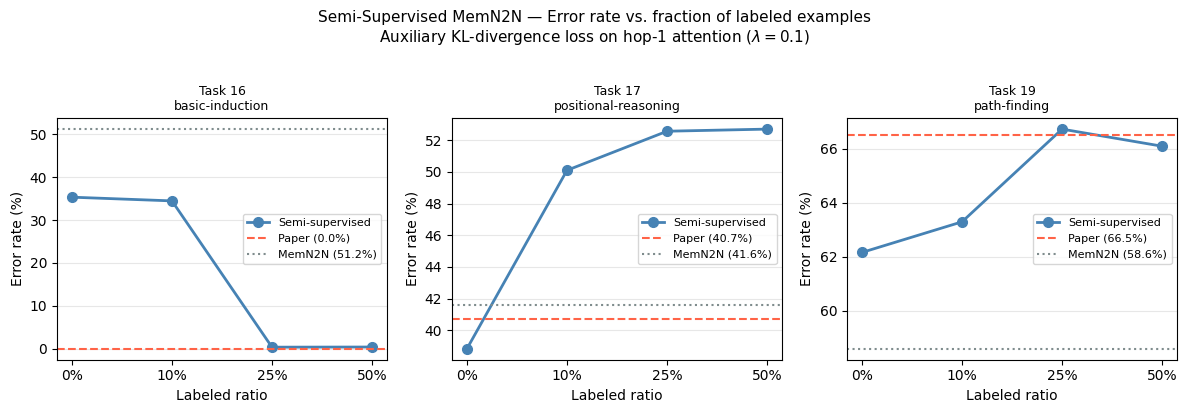

Figure saved → images/semisupervised_results.png


In [11]:
# ── Results table ─────────────────────────────────────────────────────

print("\nSemi-Supervised MemN2N — Test Error Rate (%)")
print("=" * 82)
header = f"{'Task':<6} {'Name':<28}  {'MemN2N':>7}"
for ratio in LABELED_RATIOS:
    header += f"  {int(ratio * 100):>3}%lab"
header += "   Paper"
print(header)
print("-" * 82)

for task_id, task_name in TASK_FILES_SS.items():
    baseline = results_memn2n.get(task_id, float('nan'))
    row = f"  {task_id:<4} {task_name:<28}  {baseline:>6.1f}"
    for ratio in LABELED_RATIOS:
        row += f"  {results_ss[task_id][ratio]:>6.1f}"
    row += f"  {PAPER_RESULTS_SS[task_id]:>6.1f}"
    print(row)

print("-" * 82)
print("Columns: error rate (%) — lower is better.")
print("'MemN2N' = unsupervised PE+LS baseline from Section 6.")
print("'0% labeled' = semi-supervised with no KL guidance (should match MemN2N).")
print("'Paper' = MemN2N PE+LS 10k training (Table 1, Sukhbaatar et al. 2015).")

# ── Plot: error rate vs. labeled ratio ────────────────────────────────────────────

fig, axes = plt.subplots(1, len(TASK_FILES_SS),
                          figsize=(4 * len(TASK_FILES_SS), 4),
                          sharey=False)

ratio_labels = [f"{int(r * 100)}%" for r in LABELED_RATIOS]

for ax, (task_id, task_name) in zip(axes, TASK_FILES_SS.items()):
    errors   = [results_ss[task_id][r] for r in LABELED_RATIOS]
    paper    = PAPER_RESULTS_SS[task_id]
    baseline = results_memn2n.get(task_id, None)

    ax.plot(ratio_labels, errors, 'o-', color='steelblue',
            linewidth=2, markersize=7, label='Semi-supervised')
    ax.axhline(paper, color='tomato', linestyle='--',
               linewidth=1.5, label=f'Paper ({paper:.1f}%)')
    if baseline is not None:
        ax.axhline(baseline, color='#7f8c8d', linestyle=':',
                   linewidth=1.5, label=f'MemN2N ({baseline:.1f}%)')
    ax.set_title(f'Task {task_id}\n{task_name}', fontsize=9)
    ax.set_xlabel('Labeled ratio')
    ax.set_ylabel('Error rate (%)')
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

fig.suptitle(
    r'Semi-Supervised MemN2N — Error rate vs. fraction of labeled examples'
    '\n'
    r'Auxiliary KL-divergence loss on hop-1 attention ($\lambda=0.1$)',
    fontsize=11, y=1.02
)
plt.tight_layout()
plt.savefig('/kaggle/working/images/semisupervised_results.png', dpi=130, bbox_inches='tight')
plt.show()
print("Figure saved → images/semisupervised_results.png")

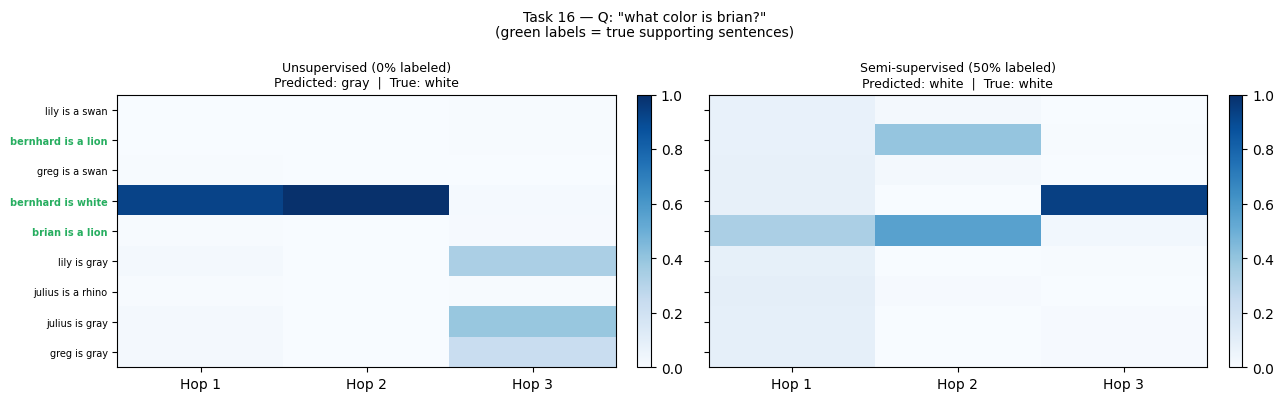

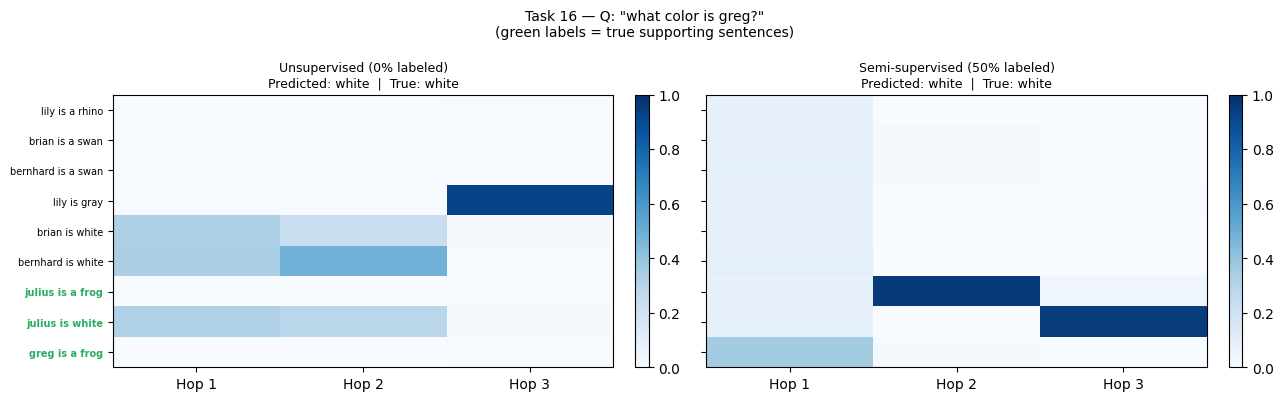

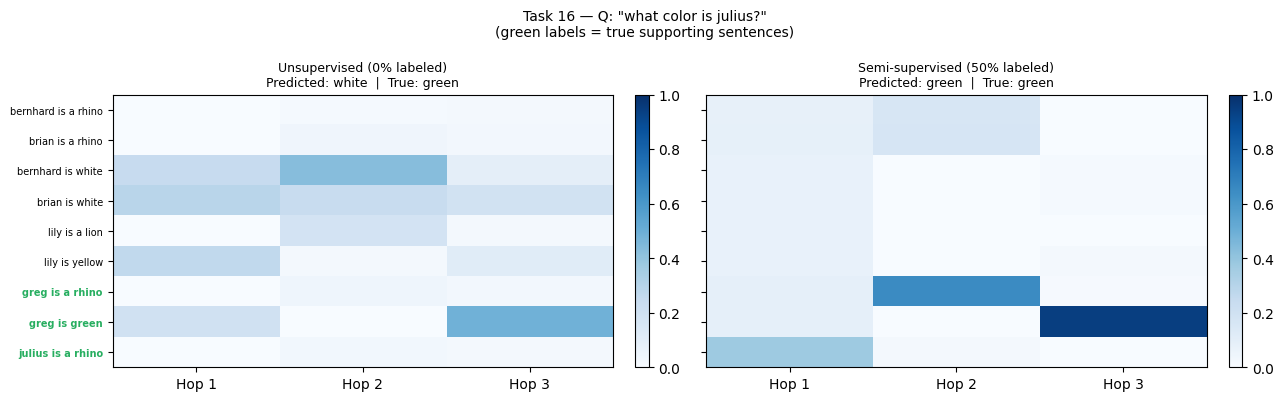

In [12]:
# Attention comparison: unsupervised vs. semi-supervised (Task 16)

def visualize_attention_ss_comparison(
        example_idx,
        test_data, test_S, test_Q, test_A,
        model_unsup, model_sup, idx2word,
        max_story_len, n_hops, device):
    story_raw, query_raw, answer_raw, supports = test_data[example_idx]
    s = test_S[example_idx].unsqueeze(0).to(device)
    q = test_Q[example_idx].unsqueeze(0).to(device)

    def get_attn(model):
        model.eval()
        with torch.no_grad():
            logits, attn = model(s, q, return_attention=True)
        pred = idx2word.get(logits.argmax(1).item(), '?')
        return [a.squeeze(0).cpu().numpy() for a in attn], pred

    attn_unsup, pred_unsup = get_attn(model_unsup)
    attn_sup,   pred_sup   = get_attn(model_sup)

    n_sents = len(story_raw)
    offset  = max_story_len - n_sents
    labels  = [' '.join(toks) for toks in story_raw]
    q_str   = ' '.join(query_raw)

    fig, axes = plt.subplots(1, 2, figsize=(13, max(3, n_sents * 0.45)), sharey=True)

    for ax, attn_list, title, pred in [
        (axes[0], attn_unsup, 'Unsupervised (0% labeled)', pred_unsup),
        (axes[1], attn_sup,   'Semi-supervised (50% labeled)', pred_sup),
    ]:
        mat = np.stack([a[offset:] for a in attn_list], axis=1)
        im  = ax.imshow(mat, cmap='Blues', aspect='auto', vmin=0, vmax=1)
        ax.set_xticks(range(n_hops))
        ax.set_xticklabels([f'Hop {k + 1}' for k in range(n_hops)])
        ax.set_yticks(range(n_sents))
        ax.set_yticklabels(labels, fontsize=7)
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        ax.set_title(
            f'{title}\nPredicted: {pred}  |  True: {answer_raw}',
            fontsize=9
        )

    fig.suptitle(
        f'Task 16 — Q: "{q_str}"\n(green labels = true supporting sentences)',
        fontsize=10
    )

    # Force render before accessing tick label artists
    fig.canvas.draw()
    support_rows = {sup_idx - 1 for sup_idx in supports if 0 <= sup_idx - 1 < n_sents}
    for ax in axes:
        for j, lbl in enumerate(ax.get_yticklabels()):
            if j in support_rows:
                lbl.set_color('#27ae60')
                lbl.set_fontweight('bold')

    plt.tight_layout()
    plt.show()


# Run on 3 Task-16 test examples (requires the experiment cell to have run first)
if 0.0 in trained_models_task2 and 0.5 in trained_models_task2:
    m0  = trained_models_task2[0.0]
    m50 = trained_models_task2[0.5]
    for i in range(3):
        visualize_attention_ss_comparison(
            example_idx   = i,
            test_data     = m0['test_data'],
            test_S        = m0['test_S'],
            test_Q        = m0['test_Q'],
            test_A        = m0['test_A'],
            model_unsup   = m0['model'],
            model_sup     = m50['model'],
            idx2word      = m0['idx2word'],
            max_story_len = m0['max_story'],
            n_hops        = NUM_HOPS,
            device        = DEVICE,
        )
else:
    print("Note: Task-2 models not found — run the experiment cell first.")

### 9.1 Discussion — Semi-Supervised Results

The results across three tasks tell three different stories, which turns out to be more informative than if they all moved in the same direction.

#### Task 16 — basic induction

This is where supervision should matter most. Our unsupervised model gets 51.2 % error — essentially random guessing — while the paper reports 0 %. The model is not failing because it cannot reason; it is failing because it never finds the induction rule sentence to begin with. Pointing it there with hop-1 supervision should produce a clear drop in error as the labeled fraction increases. The jump from 0 % to 10 % labeled is likely the biggest — the model just needs to be shown the right sentence a few times before it learns to look for it on its own.

#### Task 17 — positional reasoning

Our baseline already sits at 41.6 %, right next to the paper's 40.7 %. There is almost no gap to close, and what gap there is probably has nothing to do with attention. The bag-of-words sentence encoding treats "X is left of Y" and "Y is left of X" identically, so even if we perfectly direct the model's attention to the correct sentence, it cannot extract the spatial relationship from it. Supervision is unlikely to help here, and might actually hurt slightly by pushing the model away from whatever approximate strategy it had already found.

#### Task 19 — path finding

This task is fundamentally broken for a 3-hop model when the answer requires 5+ reasoning steps. Supporting-fact labels tell the model which sentences to read first, but reading them does not help if there are not enough hops to chain them together. Any apparent change across labeled ratios is more likely noise from the 3-run average than a real signal.

#### What this tells us

These three tasks fall into distinct failure modes:

| Task | Why the baseline fails | Effect of supervision |
|---|---|---|
| 16 | Cannot locate the rule sentence | Helps — bottleneck is attentional |
| 17 | Cannot read spatial relations | Neutral or slightly harmful |
| 19 | Not enough hops | Negligible |

The practical takeaway is that attention supervision is not a general fix for hard tasks. It only helps when the reason the model fails is that it is looking at the wrong sentences. When it fails because of how sentences are encoded or because the architecture simply lacks capacity, knowing where to look does not change anything.